<a href="https://colab.research.google.com/github/Narezkirat10/1-notebook.png/blob/main/RelianceStockForecastProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.8 MB/s eta 0:00:00


In [3]:
pip install  mpl_finance

In [4]:

!pip install statsmodels

In [5]:
!pip install pandas-visual-analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.4 MB/s eta 0:00:00


In [6]:
import time
import datetime
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# for interactive visualizations
#!pip install plotly
import plotly
import plotly.offline as py
import plotly.graph_objs as go


#from bubbly.bubbly import bubbleplot

from pandas_visual_analysis import VisualAnalysis
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.feature_selection import SelectKBest, f_classif


import warnings
warnings.filterwarnings('ignore')
from math import sqrt
from pandas import read_csv
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg

import pmdarima as pm

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pandas.tseries.offsets import DateOffset



In [7]:
import yfinance as yf
import pandas as pd

df = yf.download(
    "RELIANCE.NS",
    start="2015-12-01",
    end="2025-12-31",
    interval="1d"
)

# Convert to a clean pandas DataFrame
df = df.reset_index().copy()

df.to_csv("RELIANCE.NS.csv", index=False)

df.head()



[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


# Data PreProcessing and EDA

In [8]:
reliance=df.copy()
reliance.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [9]:
reliance[reliance.duplicated()]

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS


In [10]:
reliance.isnull().sum()

,,0
Price,Ticker,
Date,,0
Close,RELIANCE.NS,0
High,RELIANCE.NS,0
Low,RELIANCE.NS,0
Open,RELIANCE.NS,0
Volume,RELIANCE.NS,0


In [11]:
reliance[reliance.isnull().any(axis=1)]

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS


In [12]:
# Removing the row which have null value
reliance_1=reliance.dropna().reset_index(drop=True)
reliance_1.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [13]:
# Making a copy of dataset as reliance
Reliance2=reliance_1.copy()
Reliance2.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [14]:
Reliance2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2493 entries, 0 to 2492
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   (Date, )               2493 non-null   datetime64[ns]
 1   (Close, RELIANCE.NS)   2493 non-null   float64       
 2   (High, RELIANCE.NS)    2493 non-null   float64       
 3   (Low, RELIANCE.NS)     2493 non-null   float64       
 4   (Open, RELIANCE.NS)    2493 non-null   float64       
 5   (Volume, RELIANCE.NS)  2493 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 117.0 KB


In [15]:
Reliance2.describe().T

,,count,mean,min,25%,50%,75%,max,std
Price,Ticker,,,,,,,,
Date,,2493,2020-12-17 03:54:30.758122752,2015-12-01 00:00:00,2018-06-07 00:00:00,2020-12-17 00:00:00,2023-06-23 00:00:00,2025-12-30 00:00:00,NaN
Close,RELIANCE.NS,2493.0,844.138289,196.434799,430.842346,912.05426,1194.884277,1589.138062,424.025395
High,RELIANCE.NS,2493.0,852.907071,202.361109,435.100905,929.488723,1207.18242,1596.980044,427.423239
Low,RELIANCE.NS,2493.0,835.970208,192.436979,425.562484,904.436722,1182.348971,1573.85128,420.809627
Open,RELIANCE.NS,2493.0,844.601463,198.915834,430.687735,916.203212,1194.434396,1592.662006,424.170498
Volume,RELIANCE.NS,2493.0,17955217.0714,0.0,10235503.0,14117603.0,20552752.0,142683366.0,13564778.975657


In [16]:
Reliance2.shape

(2493, 6)

In [17]:
Reliance2.corr()

,Price,Date,Close,High,Low,Open,Volume
,Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Price,Ticker,,,,,,
Date,,1.000000,0.974459,0.974200,0.974641,0.974339,-0.173774
Close,RELIANCE.NS,0.974459,1.000000,0.999823,0.999807,0.999548,-0.170237
High,RELIANCE.NS,0.974200,0.999823,1.000000,0.999719,0.999787,-0.163951
Low,RELIANCE.NS,0.974641,0.999807,0.999719,1.000000,0.999772,-0.177626
Open,RELIANCE.NS,0.974339,0.999548,0.999787,0.999772,1.000000,-0.171492
Volume,RELIANCE.NS,-0.173774,-0.170237,-0.163951,-0.177626,-0.171492,1.000000


In [18]:
Reliance2['Date']=pd.to_datetime(Reliance2['Date'],format='%Y-%m-%d')
Reliance2.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [19]:
Reliance4 = Reliance2.copy()
Reliance4 = Reliance4.set_index(['Date'])
Reliance4.head()


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


# VISUALISATION

In [20]:
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import mpl_finance as mpf
from datetime import date
from matplotlib.dates import date2num
from mpl_finance import candlestick_ohlc


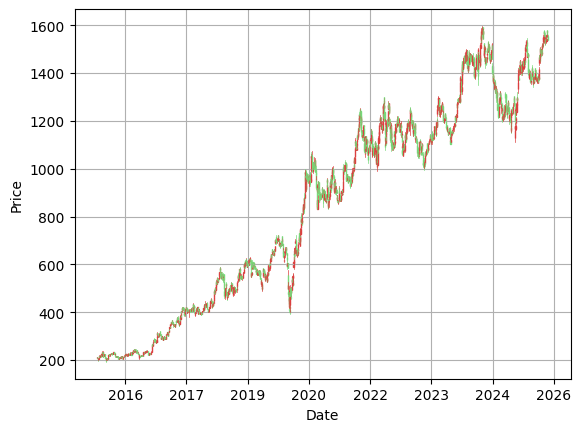

In [21]:
df_cp = reliance.copy()
df_cp.Date = date2num(pd.to_datetime(reliance.Date).dt.to_pydatetime())
ax1 = plt.subplot2grid((1,1), (0,0))
candlestick_ohlc(ax1,df_cp.values, width=0.4, colorup='#77d879', colordown='#db3f3f',alpha=1)
x_range = np.arange(df_cp.shape[0])
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mticker.MaxNLocator(10))
ax1.grid(True)
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

<Axes: >

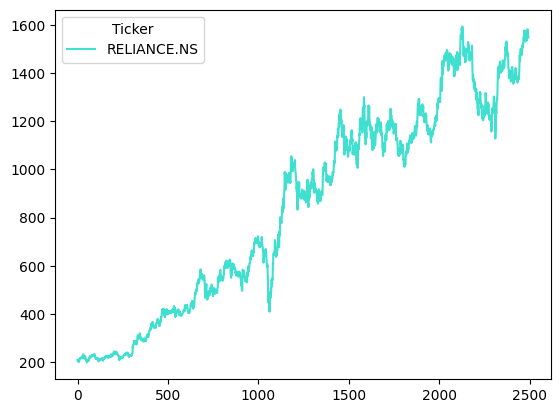

In [22]:

(reliance.Open.plot(color='turquoise'))


<Axes: >

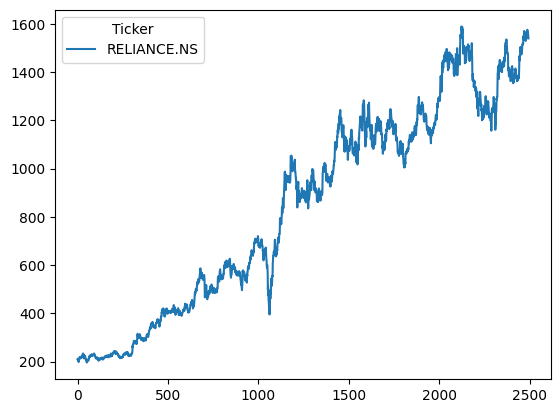

In [23]:
reliance.Close.plot()

<Axes: >

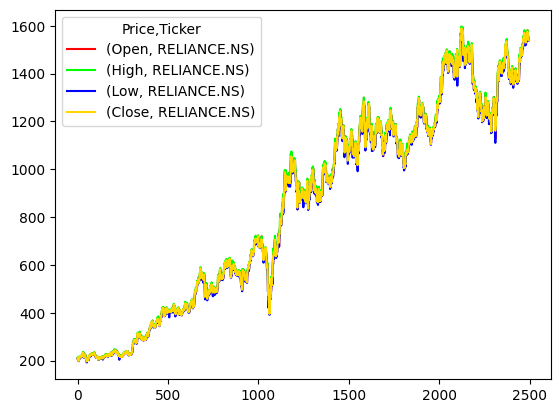

In [24]:

reliance.plot(kind = "line", y = ['Open', 'High', 'Low', 'Close'],color=['#FF0000', '#00FF00', '#0000FF','#FFD700'])

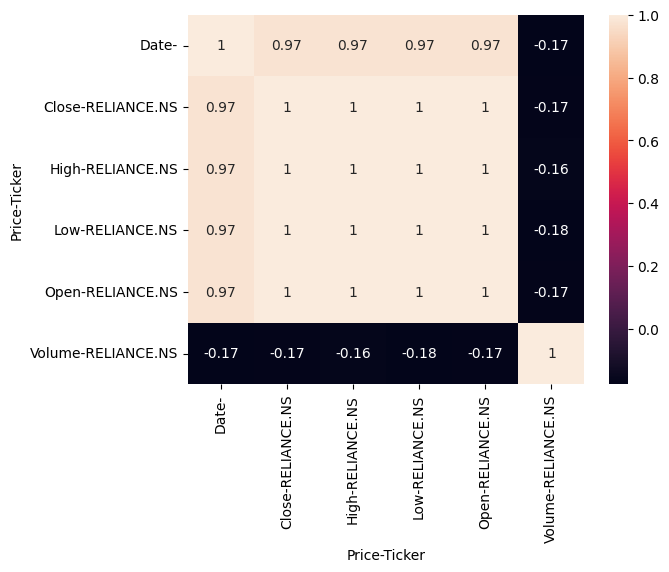

In [25]:
sns.heatmap(reliance.corr(),annot=True)
plt.show()

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.seasonal import seasonal_decompose


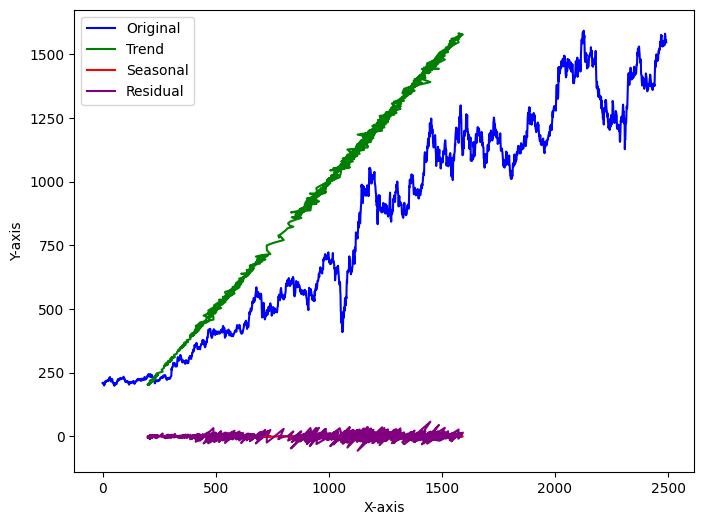

In [27]:
decomp = seasonal_decompose(df['Open'], period=5)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df['Open'], color='blue', label='Original')
ax.plot(df['Open'], decomp.trend, color='green', label='Trend')
ax.plot(df['Open'], decomp.seasonal, color='red', label='Seasonal')
ax.plot(df['Open'], decomp.resid, color='purple', label='Residual')

# Add labels and legend
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()

# Display the plot
plt.show()


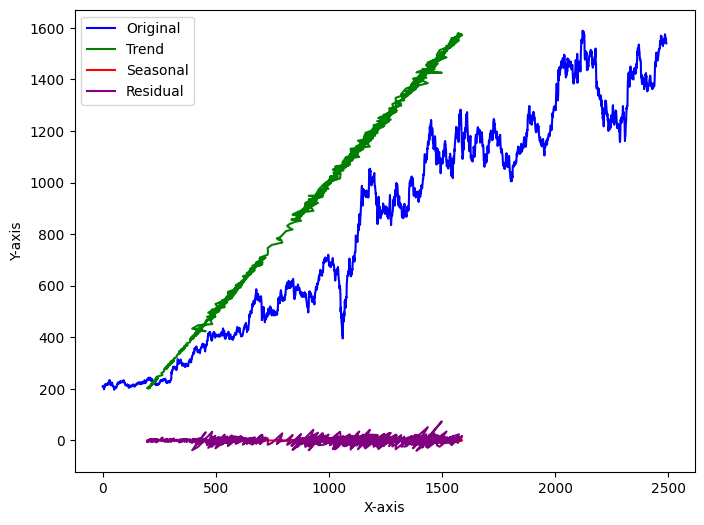

In [28]:
decomp = seasonal_decompose(df['Close'], period=5)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df['Close'], color='blue', label='Original')
ax.plot(df['Close'], decomp.trend, color='green', label='Trend')
ax.plot(df['Close'], decomp.seasonal, color='red', label='Seasonal')
ax.plot(df['Close'], decomp.resid, color='purple', label='Residual')

# Add labels and legend
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()

# Display the plot
plt.show()

Text(0.5, 1.0, 'Low')

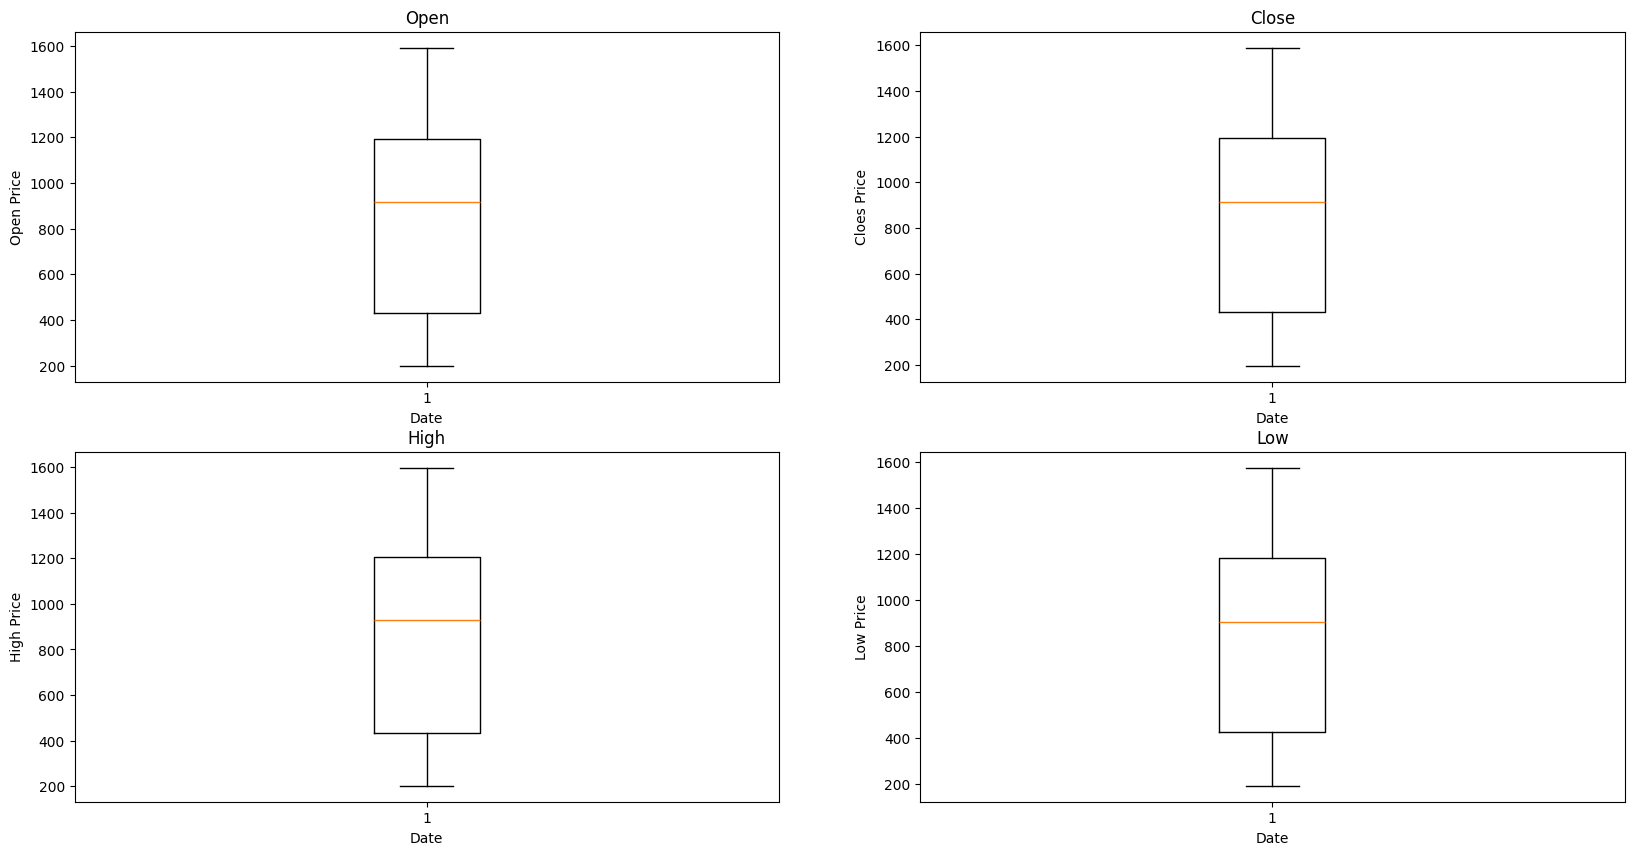

In [29]:
# Creating box-plots
plt.figure(figsize=(20,10))
#Plot 1
plt.subplot(2,2,1)
plt.boxplot(df['Open'])
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Open')
#Plot 2
plt.subplot(2,2,2)
plt.boxplot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Cloes Price')
plt.title('Close')
#Plot 3
plt.subplot(2,2,3)
plt.boxplot(df['High'])
plt.xlabel('Date')
plt.ylabel('High Price')
plt.title('High')
#Plot 4
plt.subplot(2,2,4)
plt.boxplot(df['Low'])
plt.xlabel('Date')
plt.ylabel('Low Price')
plt.title('Low')

So, from the boxplots we can see that there are no outliers in those of open,close ,high and low .

In [30]:
reliance['Year'] = reliance.Date.dt.strftime('%Y')  # Year extraction
reliance['Month'] = reliance.Date.dt.strftime('%b')
reliance.head()

Price,Date,Close,High,Low,Open,Volume,Year,Month
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379,2015,Dec
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628,2015,Dec
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395,2015,Dec
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688,2015,Dec
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909,2015,Dec


In [31]:
print(reliance.columns)


MultiIndex([(  'Date',            ''),
            ( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS'),
            (  'Year',            ''),
            ( 'Month',            '')],
           names=['Price', 'Ticker'])


In [32]:
reliance.columns = [col[0] if isinstance(col, tuple) else col for col in reliance.columns]


In [33]:
print(reliance.columns)


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Month'], dtype='object')


In [34]:
groupby_year = reliance.groupby("Year").agg({
    "Open": "mean",
    "High": "mean",
    "Low": "mean",
    "Close": "mean",
    "Volume": "sum"
})


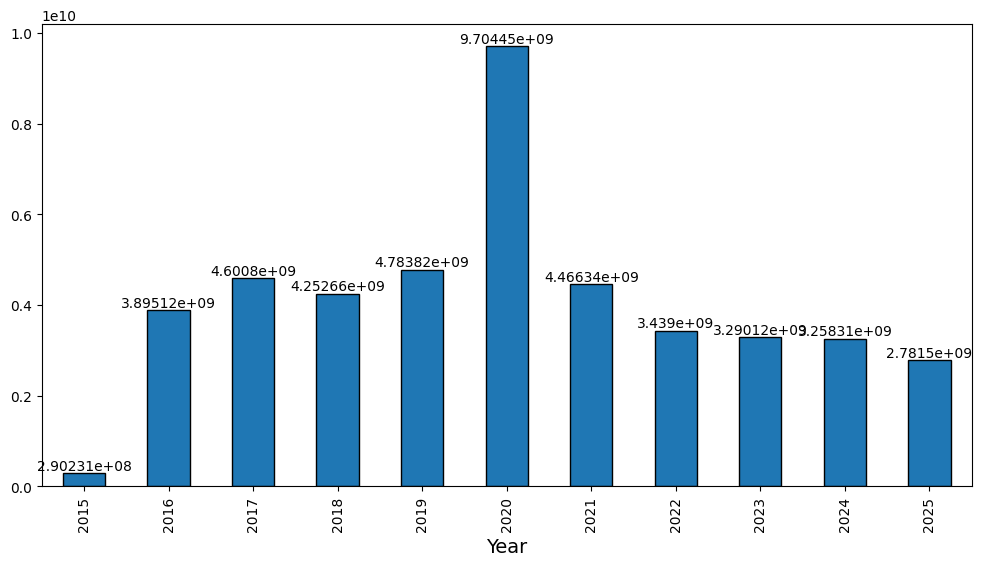

In [35]:
ax = groupby_year['Volume'].plot(kind = 'bar', figsize = (12,6), edgecolor = 'black')
plt.xlabel('Year', fontsize = 14)

for i in ax.containers :
    ax.bar_label(i,)

In [36]:
len(groupby_year['Volume'])


11

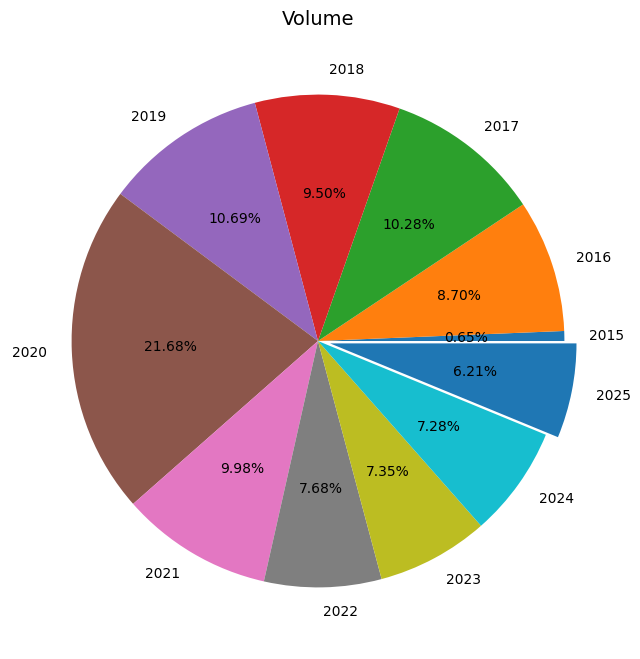

In [37]:
explode = [0] * len(groupby_year['Volume'])
explode[-1] = 0.05   # highlight last year
groupby_year['Volume'].plot(
    kind='pie',
    figsize=(8,8),
    explode=explode,
    autopct='%1.2f%%'
)
plt.title('Volume', fontsize=14)
plt.ylabel('')
plt.show()


<Axes: xlabel='Year'>

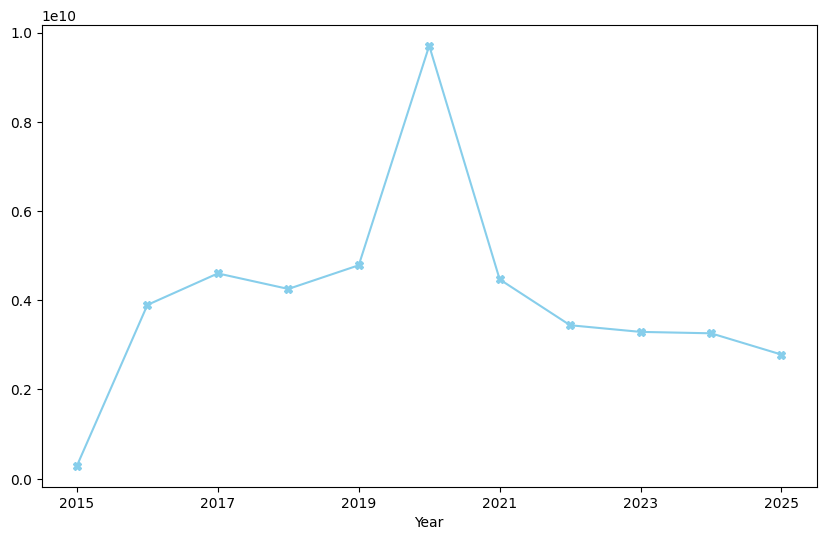

In [38]:
groupby_year['Volume'].plot(figsize = (10,6), color = 'Skyblue', marker = 'X')

Inference: High volume of stocks observed in the year 2020

In [39]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

groupby_year_month = reliance.groupby(['Year', 'Month'])[numeric_cols].sum()
groupby_year_month


Open          High           Low         Close     Volume
Year Month                                                                   
2015 Dec     4652.723887   4711.434385   4621.196378   4667.057510  290231058
2016 Apr     4085.296509   4117.430975   4039.127168   4069.640121  349334205
     Aug     4921.034027   4969.821909   4877.746121   4925.328873  270476979
     Dec     4990.616609   5050.262092   4972.966194   5013.624603  288656351
     Feb     4380.384662   4435.574103   4303.797730   4357.329529  358157727
...                  ...           ...           ...           ...        ...
2025 Mar    23545.959518  23763.689900  23336.297014  23548.997437  262251811
     May    29749.682530  30001.975191  29541.314778  29769.802612  233059332
     Nov    30324.200073  30548.900146  30159.799927  30357.700073  201185705
     Oct    29779.300049  30030.400146  29616.799927  29841.200195  249059752
     Sep    30447.300171  30615.699829  30261.699951  30428.300293  213518442

[121 rows x 5 columns]

In [40]:
reliance.pivot_table(index = 'Year', columns = 'Month', values = 'Volume')

Month,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
Year,,,,,,,,,,,,
2015,NaN,NaN,1.319232e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,1.940746e+07,1.229441e+07,1.312074e+07,1.705513e+07,2.605207e+07,1.161526e+07,1.187232e+07,1.554513e+07,1.356196e+07,1.362901e+07,1.494296e+07,2.247568e+07
2017,2.513322e+07,1.339472e+07,1.322004e+07,2.650699e+07,1.290474e+07,2.311934e+07,1.763326e+07,2.979442e+07,1.459509e+07,1.300979e+07,1.638125e+07,1.818402e+07
2018,1.311401e+07,1.549953e+07,1.670452e+07,1.668591e+07,1.313656e+07,1.981358e+07,1.683022e+07,1.528946e+07,1.261827e+07,1.790175e+07,2.869512e+07,2.186563e+07
2019,1.921984e+07,2.615070e+07,1.786033e+07,1.927793e+07,2.032834e+07,1.502461e+07,1.534384e+07,2.175080e+07,2.437973e+07,1.826915e+07,1.796632e+07,2.089763e+07
2020,5.757146e+07,3.954559e+07,2.292617e+07,1.988880e+07,1.900551e+07,5.808441e+07,3.916801e+07,4.738890e+07,5.290632e+07,4.682833e+07,2.680982e+07,3.730544e+07
2021,1.721999e+07,1.343238e+07,1.245286e+07,2.612424e+07,3.250821e+07,1.025794e+07,2.288900e+07,2.003128e+07,1.871872e+07,1.606181e+07,1.168874e+07,1.566650e+07
2022,1.553390e+07,1.176015e+07,8.993065e+06,1.255510e+07,1.372815e+07,2.032833e+07,1.598640e+07,1.496417e+07,1.922598e+07,1.077385e+07,1.077701e+07,1.170610e+07
2023,1.234340e+07,1.356705e+07,1.277313e+07,1.528557e+07,1.360141e+07,1.982166e+07,1.065351e+07,1.657303e+07,9.934956e+06,1.028575e+07,1.028367e+07,1.585169e+07


In [41]:
reliance['Daily_Gain'] = reliance['Close'].pct_change(periods = 1)
reliance

,Date,Close,High,Low,Open,Volume,Year,Month,Daily_Gain
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379,2015,Dec,NaN
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628,2015,Dec,0.012475
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395,2015,Dec,-0.000767
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688,2015,Dec,-0.012024
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909,2015,Dec,-0.013880
...,...,...,...,...,...,...,...,...,...
2488,2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,2025,Dec,-0.007958
2489,2025-12-25,1558.199951,1558.199951,1558.199951,1558.199951,0,2025,Dec,0.000000
2490,2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,2025,Dec,0.000642
2491,2025-12-29,1545.599976,1558.099976,1543.599976,1554.900024,5972105,2025,Dec,-0.008722


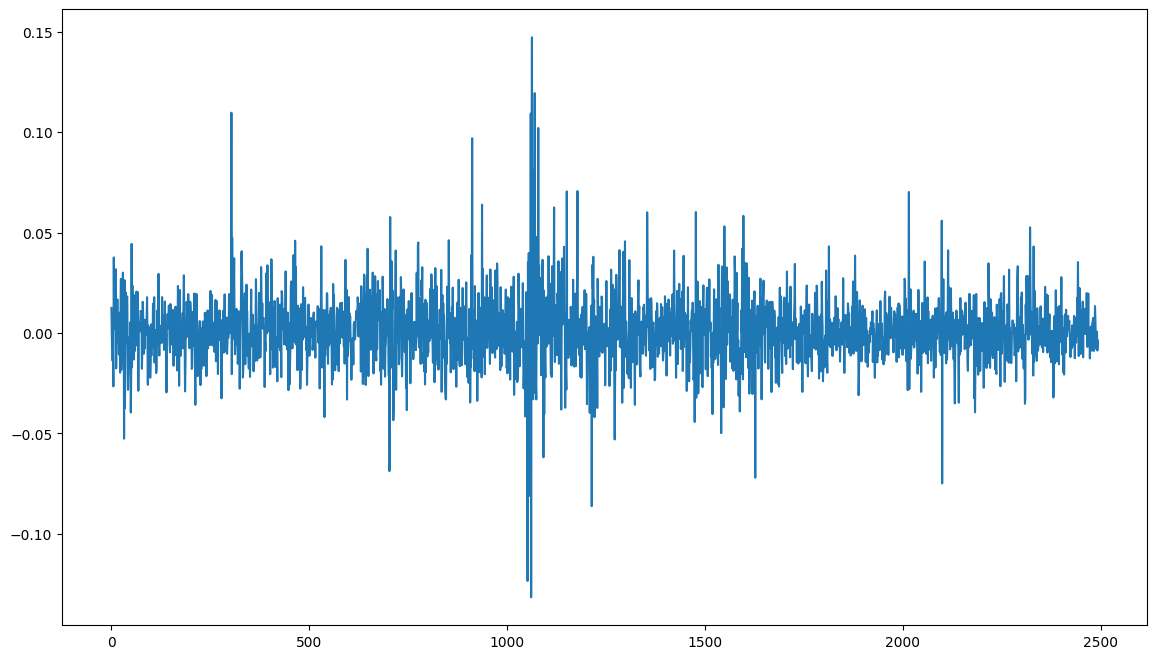

In [42]:
plt.figure(figsize = (14,8))
plt.plot(reliance.index,reliance['Daily_Gain'])
plt.show()

<Axes: xlabel='Year', ylabel='Open'>

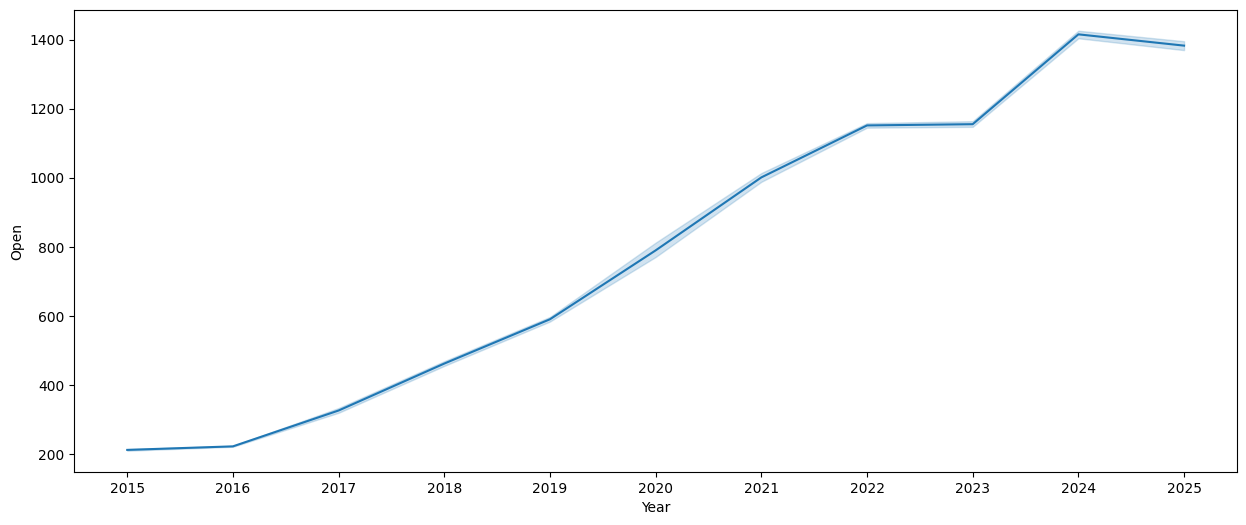

In [43]:
plt.figure(figsize = (15,6))
sns.lineplot(x = reliance['Year'], y = reliance['Open'])

In [44]:
Reliance1=reliance.copy()
Reliance1

,Date,Close,High,Low,Open,Volume,Year,Month,Daily_Gain
0,2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379,2015,Dec,NaN
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628,2015,Dec,0.012475
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395,2015,Dec,-0.000767
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688,2015,Dec,-0.012024
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909,2015,Dec,-0.013880
...,...,...,...,...,...,...,...,...,...
2488,2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,2025,Dec,-0.007958
2489,2025-12-25,1558.199951,1558.199951,1558.199951,1558.199951,0,2025,Dec,0.000000
2490,2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,2025,Dec,0.000642
2491,2025-12-29,1545.599976,1558.099976,1543.599976,1554.900024,5972105,2025,Dec,-0.008722


In [45]:
ReliancePivot= pd.pivot_table(Reliance1, values = "Close", columns = "Year", index = "Month")
ReliancePivot.head()

Year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Month,,,,,,,,,,,
Apr,NaN,226.091118,305.330483,413.103697,605.595048,568.900177,889.305205,1216.059153,1074.395680,1457.295148,1264.709402
Aug,NaN,223.878585,349.880942,546.474139,549.157417,957.099464,979.781712,1189.698938,1239.838950,1476.905105,1389.978432
Dec,212.138978,227.892027,406.160632,498.605118,699.147926,897.040599,1086.777423,1189.252541,1240.630048,1255.952904,1549.895452
Feb,NaN,207.491882,237.485586,407.442238,555.760045,644.562815,911.964746,1077.467340,1080.310663,1451.717099,1231.342126
Jan,NaN,222.153019,231.712243,415.400841,515.858420,678.699811,887.665387,1115.590497,1128.525949,1338.093785,1247.989560


<Axes: xlabel='Month'>

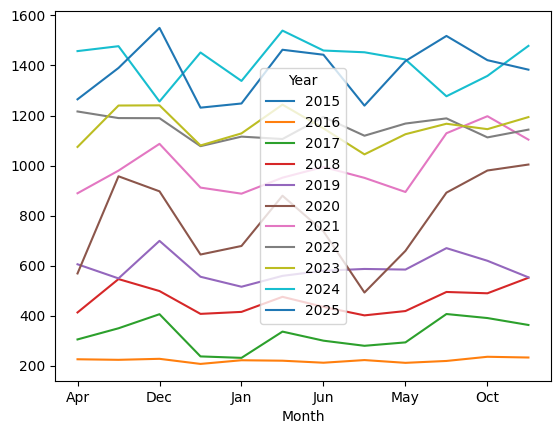

In [46]:
 ReliancePivot.plot()

array([[<Axes: xlabel='Month'>, <Axes: xlabel='Month'>,
        <Axes: xlabel='Month'>, <Axes: xlabel='Month'>],
       [<Axes: xlabel='Month'>, <Axes: xlabel='Month'>,
        <Axes: xlabel='Month'>, <Axes: xlabel='Month'>],
       [<Axes: xlabel='Month'>, <Axes: xlabel='Month'>,
        <Axes: xlabel='Month'>, <Axes: xlabel='Month'>],
       [<Axes: xlabel='Month'>, <Axes: xlabel='Month'>,
        <Axes: xlabel='Month'>, <Axes: xlabel='Month'>]], dtype=object)

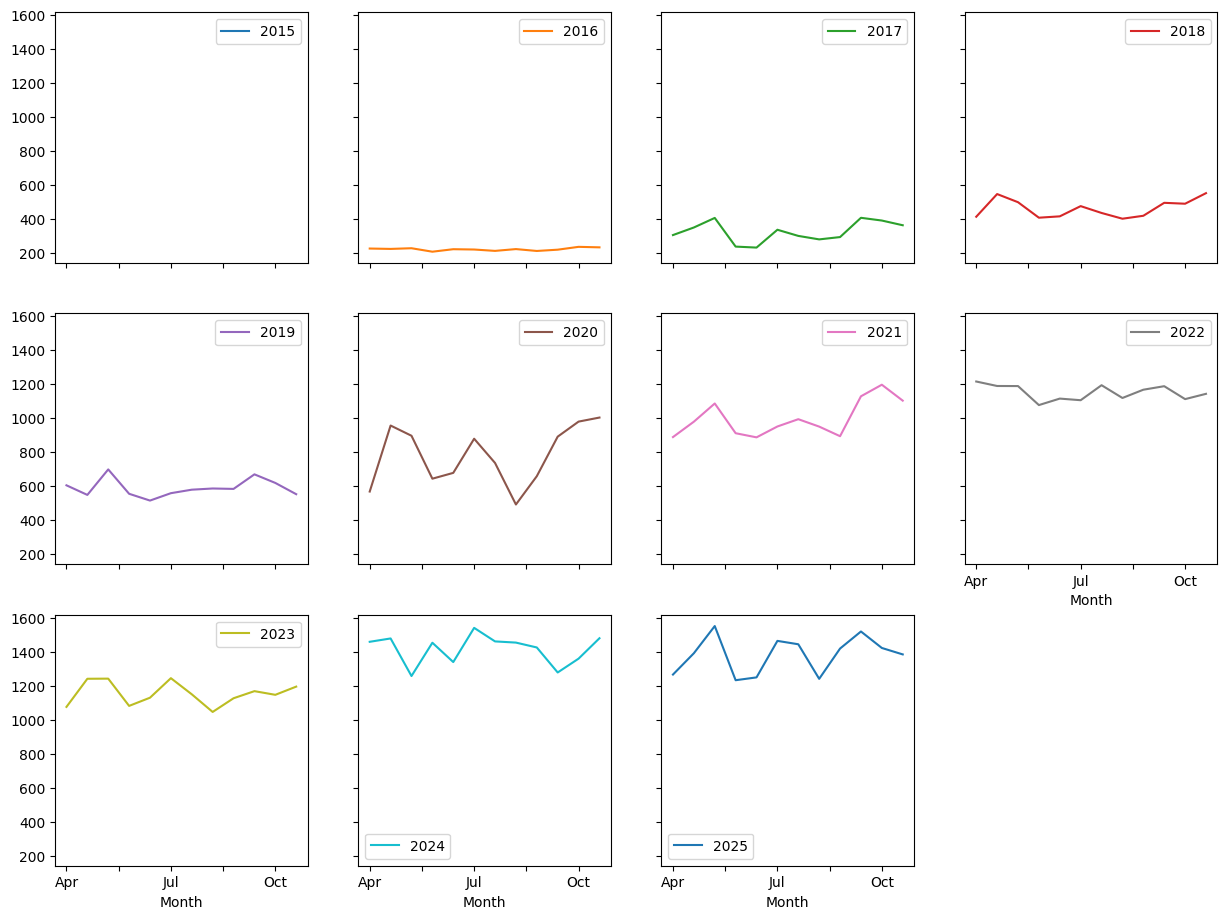

In [47]:
ReliancePivot.plot(subplots = True, figsize=(15, 15), layout=(4,4), sharey=True)

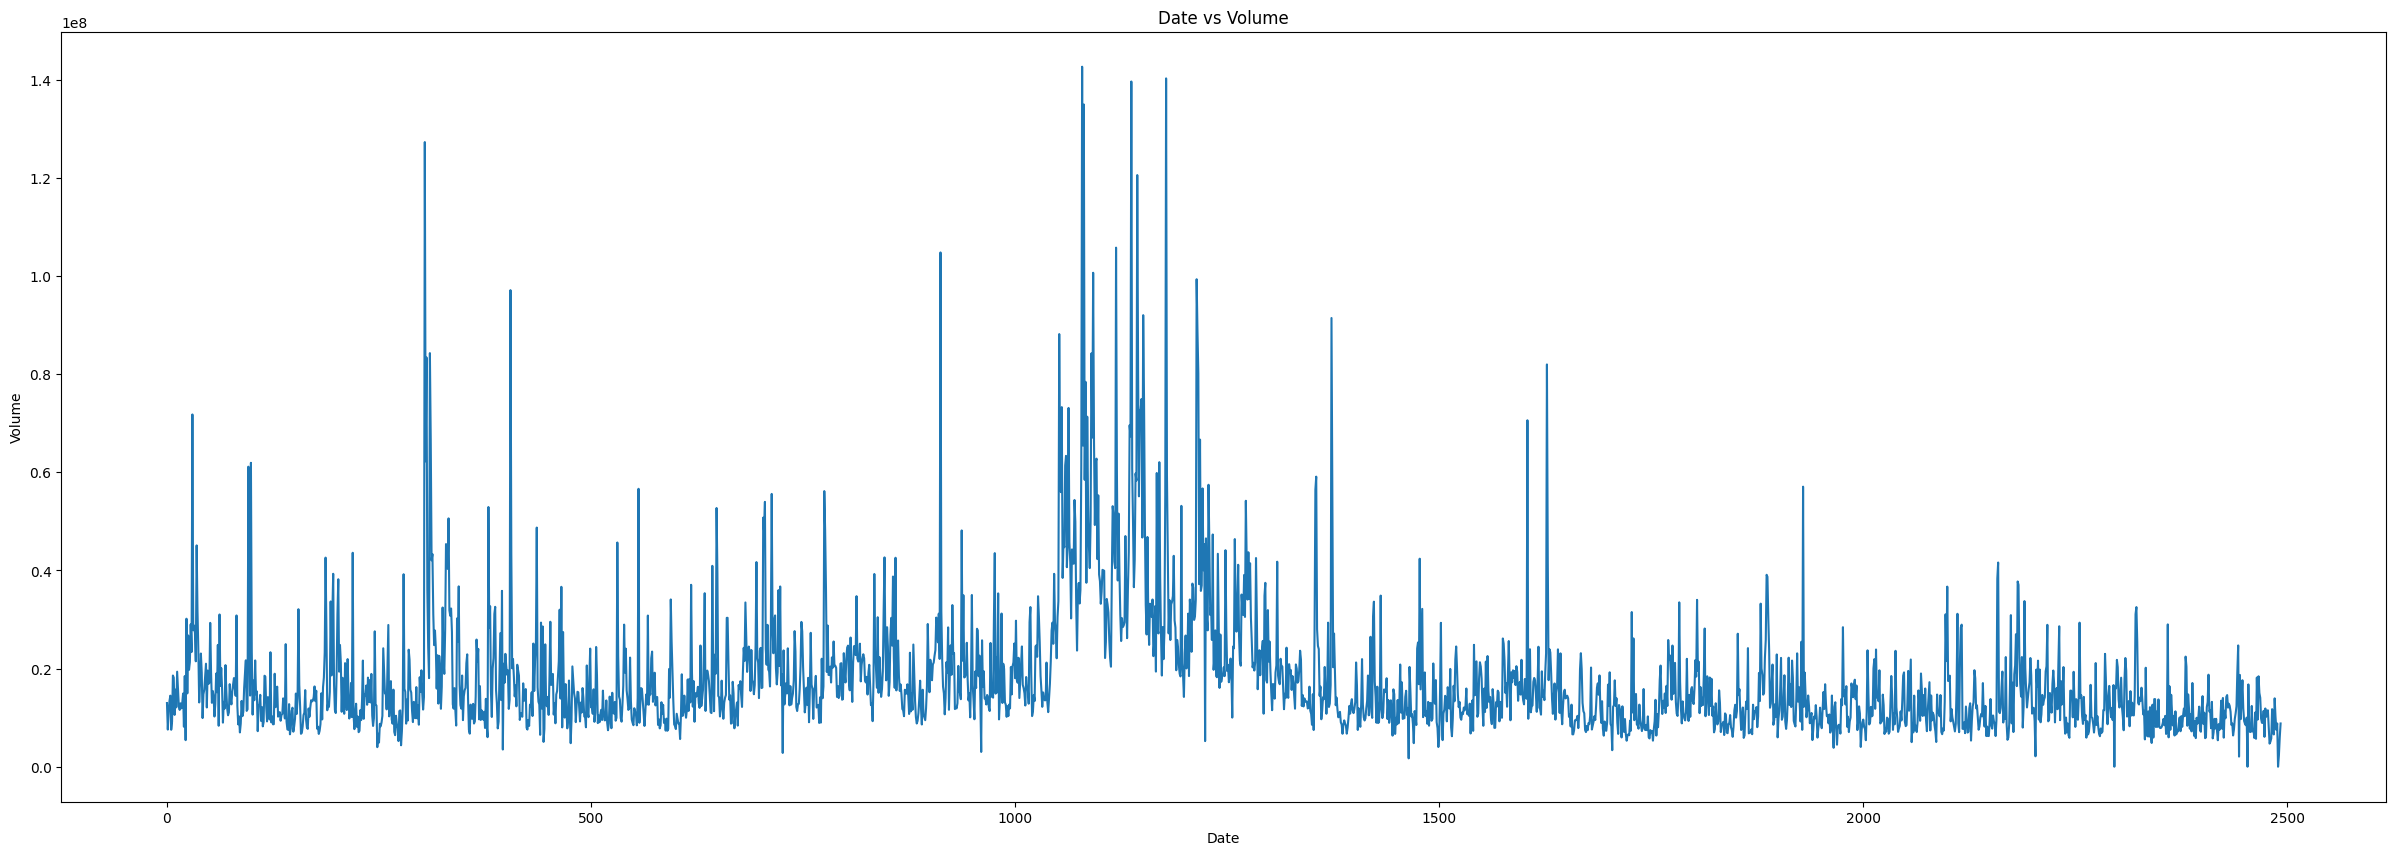

In [48]:
figure=plt.figure(figsize=(30,10))
plt.plot(Reliance1['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Date vs Volume')
plt.show()

In [50]:
Reliance1 = Reliance1.rolling(window = 30).mean()
print(Reliance1)

DataError: Cannot aggregate non-numeric type: datetime64[ns]

Text(0.5, 1.0, 'Rollng Mean')

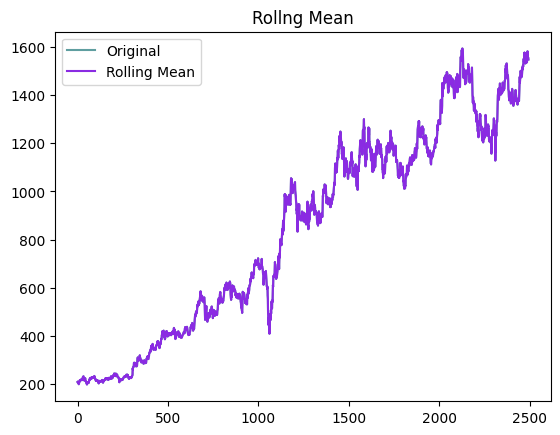

In [52]:
#plot rolling statistics
org = plt.plot(reliance['Open'], color =  '#5F9EA0', label ='Original')
mean = plt.plot(Reliance1['Open'], color = '#8A2BE2', label ='Rolling Mean')
plt.legend(loc = 'best')
plt.title ('Rollng Mean')

Long term and short term trends can be identified using the Moving Average graphs

-In long term, Stock price is in upward trend

-Short term trends can be identified from MA-30 chart

-Stock had a major short term downtrend during the year 2020

-It may be due to the bearish market during the Covid-19 outbraek

# Transformations for normalising the data

In [53]:
Reliance2=df.copy()
Reliance2=Reliance2.drop([" Adj Close"],axis=1).reset_index(drop=True)
Reliance2

KeyError: ' Adj Close'

(array([351., 174., 240., 272.,  91., 148., 267., 484., 219., 247.]),
 array([ 56.10837985,  75.20870626,  94.30903268, 113.40935909,
        132.50968551, 151.61001192, 170.71033834, 189.81066475,
        208.91099117, 228.01131758, 247.111644  ]),
 <BarContainer object of 10 artists>)

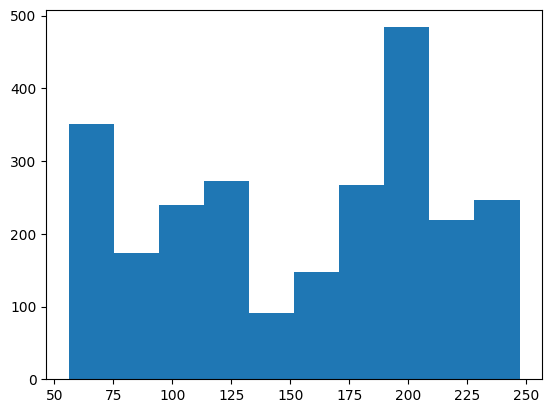

In [54]:
close_values = Reliance2['Close'].to_numpy().ravel()
Reliance2['Close_boxcox'], _ = stats.boxcox(close_values)
plt.hist(Reliance2['Close_boxcox'])


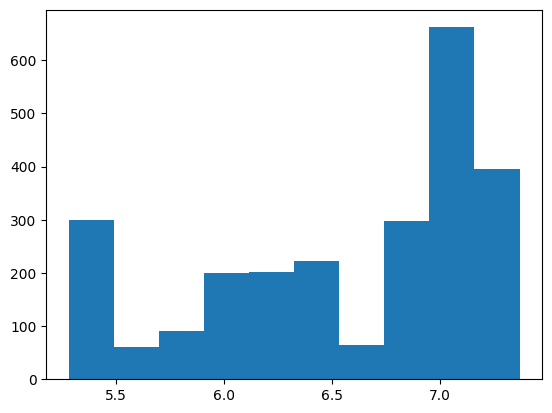

In [55]:
#Log Transform
close_vals = Reliance2['Close'].to_numpy().ravel()
Reliance2['logClose'] = np.log(close_vals)

plt.hist(Reliance2['logClose'])
plt.show()


(array([313., 138., 214., 277., 173.,  44., 263., 478., 296., 297.]),
 array([14.01551994, 16.6003674 , 19.18521486, 21.77006232, 24.35490978,
        26.93975725, 29.52460471, 32.10945217, 34.69429963, 37.27914709,
        39.86399455]),
 <BarContainer object of 10 artists>)

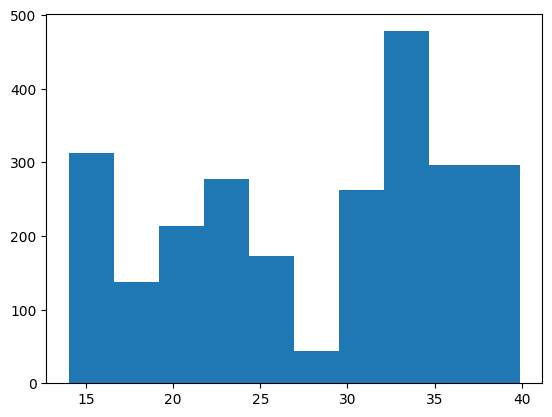

In [56]:
#square root transform
Reliance2['sqr_Close']=np.sqrt(Reliance2['Close'])
plt.hist(Reliance2.sqr_Close)

(array([1229.,  227.,  295.,  170.,  153.,   49.,   64.,   19.,  210.,
          77.]),
 array([0.00062927, 0.00107542, 0.00152157, 0.00196771, 0.00241386,
        0.00286001, 0.00330616, 0.0037523 , 0.00419845, 0.0046446 ,
        0.00509075]),
 <BarContainer object of 10 artists>)

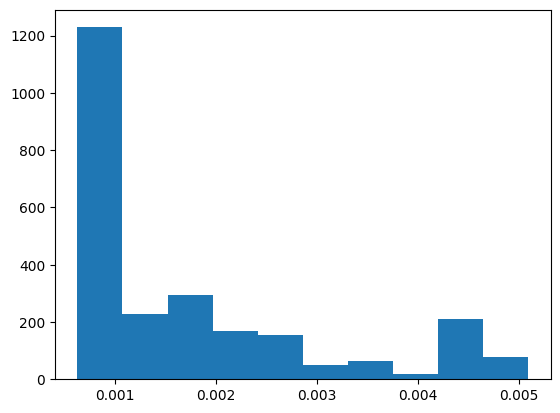

In [57]:
#Reciprocal transformation
Reliance2['Rec_Close']=1/(Reliance2['Close'])
plt.hist(Reliance2.Rec_Close)

array([[<Axes: title={'center': "('Date', '')"}>,
        <Axes: title={'center': "('Close', 'RELIANCE.NS')"}>,
        <Axes: title={'center': "('High', 'RELIANCE.NS')"}>],
       [<Axes: title={'center': "('Low', 'RELIANCE.NS')"}>,
        <Axes: title={'center': "('Open', 'RELIANCE.NS')"}>,
        <Axes: title={'center': "('Volume', 'RELIANCE.NS')"}>],
       [<Axes: title={'center': "('Close_boxcox', '')"}>,
        <Axes: title={'center': "('logClose', '')"}>,
        <Axes: title={'center': "('sqr_Close', '')"}>],
       [<Axes: title={'center': "('Rec_Close', '')"}>, <Axes: >,
        <Axes: >]], dtype=object)

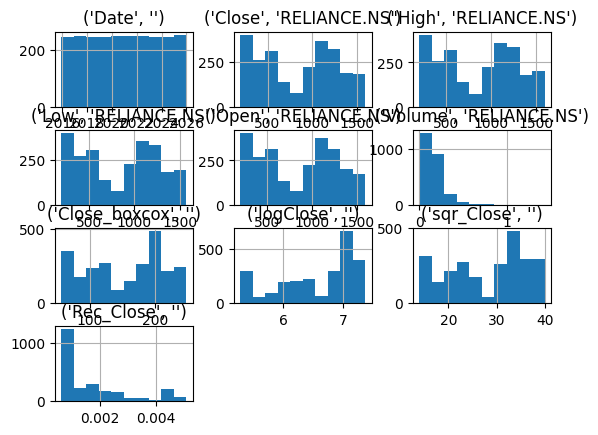

In [58]:
Reliance2.hist()

In [59]:
def diagnostic_plots(Reliance3, variable):
    # function to plot a histogram and a Q-Q plot
    # side by side, for a certain variable

    plt.figure(figsize=(15,6))
    plt.subplot(1, 2, 1)
    Reliance3[variable].hist()

    plt.subplot(1, 2, 2)
    stats.probplot(Reliance3[variable], dist="norm", plot=plt)

    sns.set_style(style='white')
    plt.show()

# Scaling Transform

Mean: Ticker
RELIANCE.NS    844.138289
dtype: float64
Standard Deviation: Ticker
RELIANCE.NS    424.025395
dtype: float64


ValueError: Cannot calculate a linear regression if all x values are identical

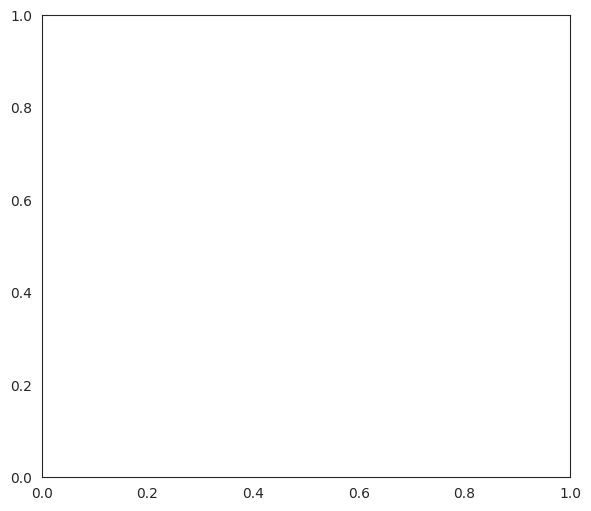

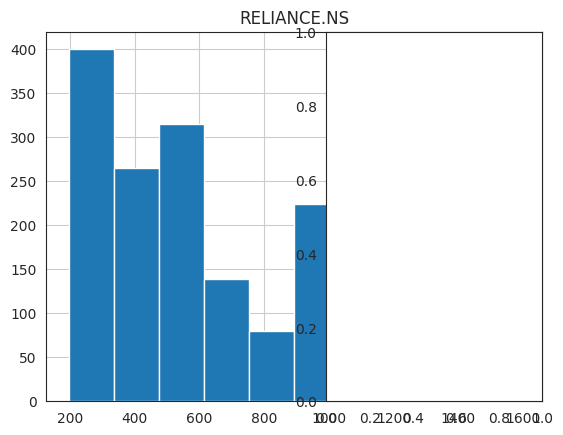

In [60]:
Reliance3=Reliance2[['Close']]

print('Mean:', Reliance2['Close'].mean())
print('Standard Deviation:', Reliance2['Close'].std())

sns.set_style(style='white')
diagnostic_plots(Reliance2,'Close')

Standard Scaling Transform

Mean: -9.120484373976416e-17
Standard Deviation: 1.0002006219299946


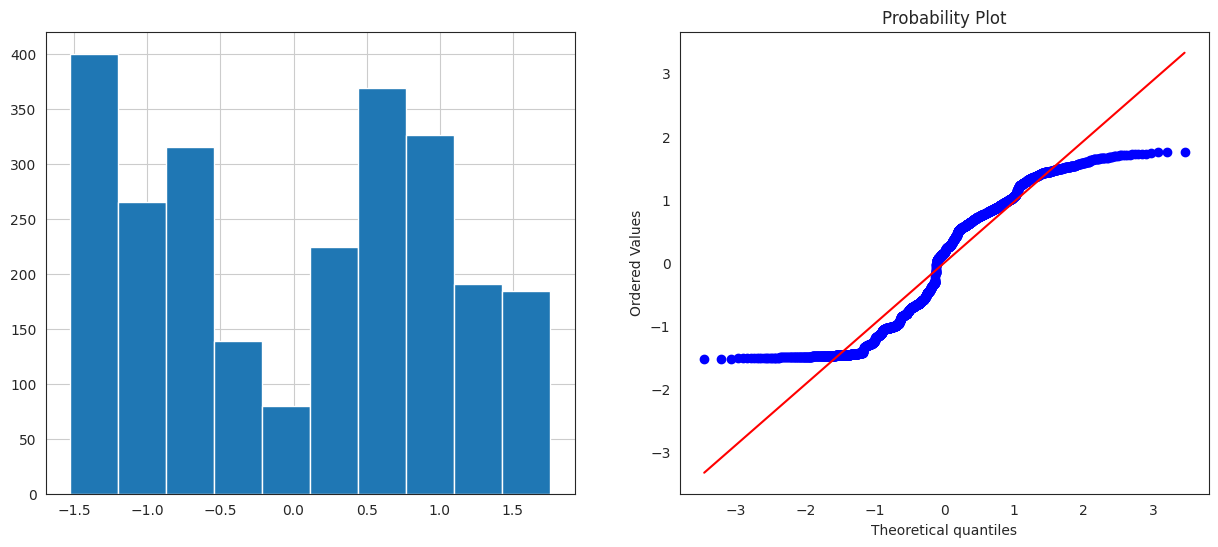

In [61]:
standard_scaler = StandardScaler()
Reliance3['Close_scaled'] = standard_scaler.fit_transform(Reliance3[['Close']])

print('Mean:', Reliance3['Close_scaled'].mean())
print('Standard Deviation:', Reliance3['Close_scaled'].std())

diagnostic_plots(Reliance3,'Close_scaled')

Mean: 0.4650692702826928
Standard Deviation: 0.30446212511625437


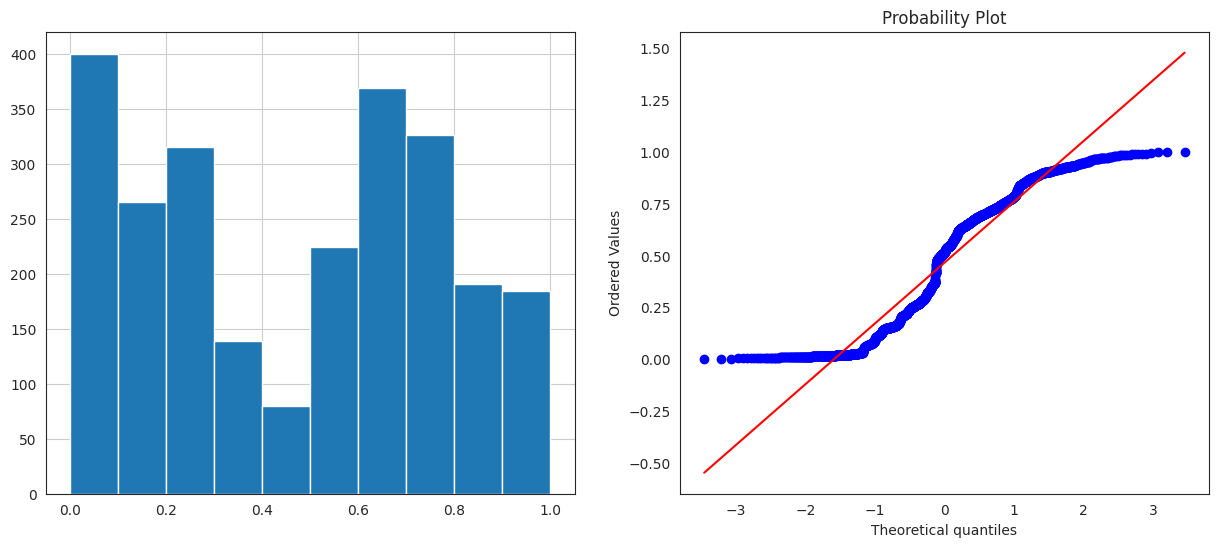

In [62]:
minmax_scaler = MinMaxScaler()
Reliance3['Close_min_max_scaled'] = minmax_scaler.fit_transform(Reliance3[['Close']])

print('Mean:', Reliance3['Close_min_max_scaled'].mean())
print('Standard Deviation:', Reliance3['Close_min_max_scaled'].std())

diagnostic_plots(Reliance3,'Close_min_max_scaled')

Mean: 0.5000033702506047
Standard Deviation: 0.2888460179749826


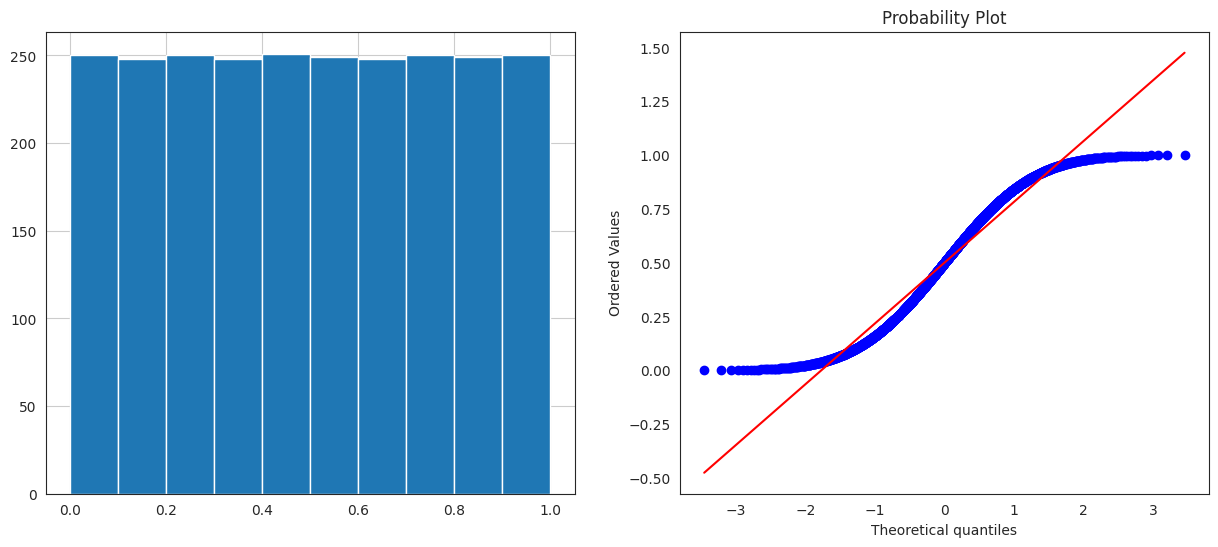

In [63]:
qtrans = QuantileTransformer()
Reliance3['Close_q_trans_uniform'] = qtrans.fit_transform(Reliance3[['Close']])

print('Mean:', Reliance3['Close_q_trans_uniform'].mean())
print('Standard Deviation:', Reliance3['Close_q_trans_uniform'].std())

diagnostic_plots(Reliance3,'Close_q_trans_uniform')

Mean: 1.0616450029838076e-05
Standard Deviation: 1.0076553333105422


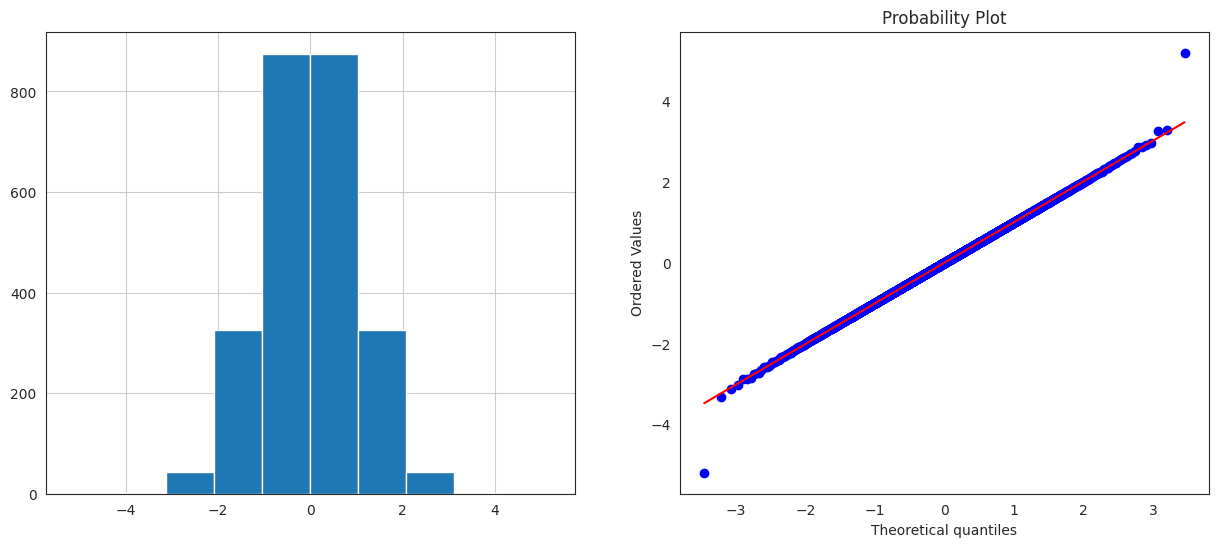

In [64]:
qtrans = QuantileTransformer(output_distribution='normal', random_state=0)
Reliance3['Close_q_trans_normal'] = qtrans.fit_transform(Reliance3[['Close']])

print('Mean:', Reliance3['Close_q_trans_normal'].mean())
print('Standard Deviation:', Reliance3['Close_q_trans_normal'].std())

diagnostic_plots(Reliance3,'Close_q_trans_normal')

In [65]:
Reliance3.head()

Price,Close,Close_scaled,Close_min_max_scaled,Close_q_trans_uniform,Close_q_trans_normal
Ticker,RELIANCE.NS,,,,
0,209.295013,-1.497483,0.009234,0.013084,-2.223724
1,211.906067,-1.491324,0.011109,0.018027,-2.096314
2,211.743515,-1.491707,0.010992,0.017530,-2.107664
3,209.197495,-1.497713,0.009164,0.012104,-2.253798
4,206.293930,-1.504562,0.007079,0.006049,-2.509254


In [66]:
from statsmodels.tsa.stattools import adfuller



In [67]:
dk=df.copy()
#dk=dk.drop(["Adj Close"],axis=1).reset_index(drop=True)
dk=dk.dropna().reset_index(drop=True)
dk=dk.set_index('Date')
dk.head()


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [68]:
print("Result of Dickey-Fuller Test::")
dftest = adfuller(dk['Open'],autolag ='AIC')
dfoutput = pd.Series(dftest[0:4], index = ['Test Statistics', 'p-value', '#lag Used', 'Number of Observation Used'])
for key,value in dftest[4].items():
  dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

if dftest[0] < dftest[4]['5%']:
  print ("Reject Ho - Time Series is Stationary")
else:
  print ("Failed to reject Ho - Time Series is Non-Stationary")

Result of Dickey-Fuller Test::
Test Statistics                 -0.716406
p-value                          0.842454
#lag Used                        0.000000
Number of Observation Used    2492.000000
Critical Value (1%)             -3.432977
Critical Value (5%)             -2.862701
Critical Value (10%)            -2.567388
dtype: float64
Failed to reject Ho - Time Series is Non-Stationary


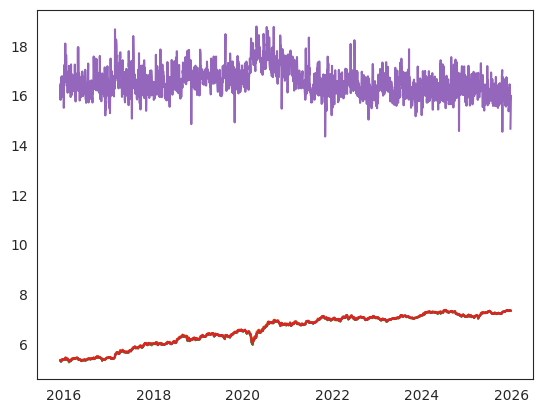

In [69]:
dk_logscale = np.log(dk)
plt.plot(dk_logscale)

In [70]:
MovingAvg =dk_logscale.rolling(window = 30).mean()
print(MovingAvg)

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2015-12-01         NaN         NaN         NaN         NaN         NaN
2015-12-02         NaN         NaN         NaN         NaN         NaN
2015-12-03         NaN         NaN         NaN         NaN         NaN
2015-12-04         NaN         NaN         NaN         NaN         NaN
2015-12-07         NaN         NaN         NaN         NaN         NaN
...                ...         ...         ...         ...         ...
2025-12-24    7.342791    7.348909    7.336451    7.342368   16.028408
2025-12-25    7.343818    7.349691    7.337569    7.343305         NaN
2025-12-26    7.344691    7.350558    7.338633    7.344377         NaN
2025-12-29    7.345285    7.351302    7.339333    7.345114         NaN
2025-12-30    7.345730    7.351861    7.339930    7.345664         NaN

[2493

Text(0.5, 1.0, 'Rollng Mean')

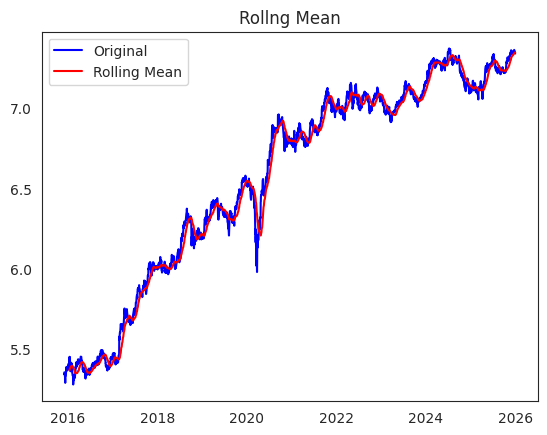

In [71]:
org = plt.plot(dk_logscale['Close'], color = 'blue', label ='Original')
mean = plt.plot(MovingAvg['Close'], color = 'red', label ='Rolling Mean')
plt.legend(loc = 'best')
plt.title ('Rollng Mean')

In [72]:
logScaleMinusMovingAvg = dk_logscale - MovingAvg
logScaleMinusMovingAvg.head()

logScaleMinusMovingAvg.dropna(inplace=True)
logScaleMinusMovingAvg.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2016-01-12,0.054237,0.063415,0.061072,0.067161,0.497953
2016-01-13,0.080205,0.082433,0.064059,0.062411,1.563260
2016-01-14,0.063252,0.071092,0.066702,0.069360,0.571839
2016-01-15,0.071039,0.075696,0.075557,0.071796,0.574242
2016-01-18,0.015282,0.067099,0.018505,0.073344,0.496669


In [73]:
def text_stationarity(test_stationarity):

    rollmean = test_stationarity.rolling(window = 30).mean()
    rollstd = test_stationarity.rolling(window = 30).std()

    #plot rolling statistics
    org = plt.plot(test_stationarity, color = 'Skyblue', label ='Original')
    mean = plt.plot(rollmean, color = 'Coral', label ='RollingMean')
    std = plt.plot(rollstd, color = 'black', label ='RollingStd')
    plt.legend(loc = 'best')
    plt.title ('Rollng mean & Standard Deviation')

    print("Result of Dickey-Fuller Test::")
    dftest = adfuller(test_stationarity,autolag ='AIC')
    dfoutput = pd.Series(dftest[0:4], index = ['Test Statistics', 'p-value', '#lag Used', 'Number of Observation Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

    if dftest[0] < dftest[4]['5%']:
        print ("Reject Ho - Time Series is Stationary")
    else:
        print ("Failed to reject Ho - Time Series is Non-Stationary")

Result of Dickey-Fuller Test::
Test Statistics              -9.480573e+00
p-value                       3.882854e-16
#lag Used                     1.400000e+01
Number of Observation Used    2.385000e+03
Critical Value (1%)          -3.433095e+00
Critical Value (5%)          -2.862753e+00
Critical Value (10%)         -2.567416e+00
dtype: float64
Reject Ho - Time Series is Stationary


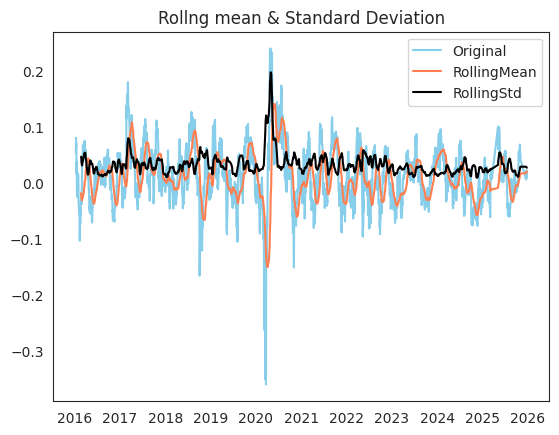

In [74]:
text_stationarity(logScaleMinusMovingAvg['Close'])

# Exponential Decay Transformation

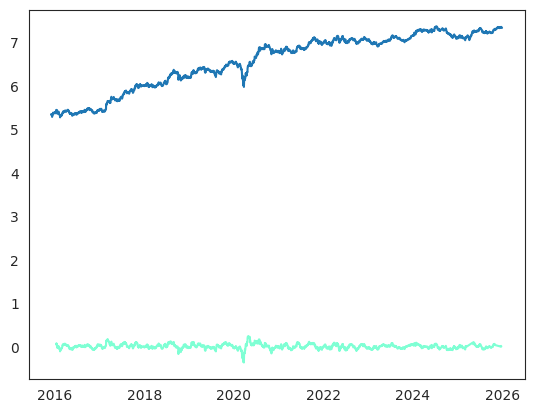

In [75]:
expDecayWtAvg = dk_logscale.ewm(halflife=30,adjust = True).mean()
plt.plot(dk_logscale['Close'])
plt.plot(logScaleMinusMovingAvg['Close'], color = '#7FFFD4')

In [76]:
expDecayWtAvg.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-12-01,5.343745,5.357012,5.338919,5.341776,16.379027
2015-12-02,5.350016,5.357477,5.340626,5.342955,16.106492
2015-12-03,5.351844,5.360837,5.344573,5.346388,16.153982
2015-12-04,5.349628,5.359159,5.343151,5.347412,16.221262
2015-12-07,5.345373,5.357465,5.339745,5.346547,16.277217


Result of Dickey-Fuller Test::
Test Statistics              -5.854843e+00
p-value                       3.519763e-07
#lag Used                     1.100000e+01
Number of Observation Used    2.481000e+03
Critical Value (1%)          -3.432988e+00
Critical Value (5%)          -2.862706e+00
Critical Value (10%)         -2.567391e+00
dtype: float64
Reject Ho - Time Series is Stationary


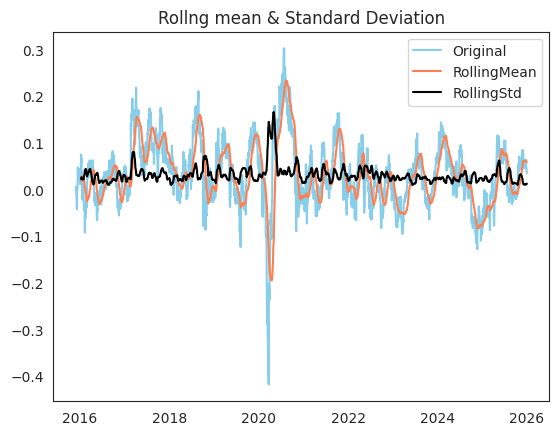

In [77]:
logScaleMinusexpMovingAvg = dk_logscale - expDecayWtAvg
text_stationarity(logScaleMinusexpMovingAvg['Close'])

Time Shift

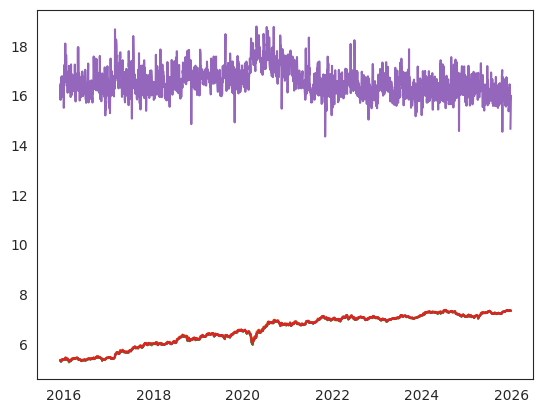

In [78]:
ReliancelogDiffShifting = dk_logscale - dk_logscale.shift()
plt.plot(dk_logscale)

Result of Dickey-Fuller Test::
Test Statistics              -1.508263e+01
p-value                       8.411811e-28
#lag Used                     1.000000e+01
Number of Observation Used    2.481000e+03
Critical Value (1%)          -3.432988e+00
Critical Value (5%)          -2.862706e+00
Critical Value (10%)         -2.567391e+00
dtype: float64
Reject Ho - Time Series is Stationary


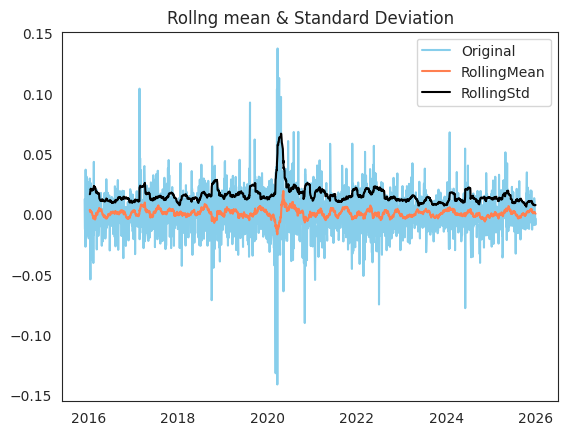

In [79]:
ReliancelogDiffShifting.dropna(inplace=True)
text_stationarity(ReliancelogDiffShifting['Close'])

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

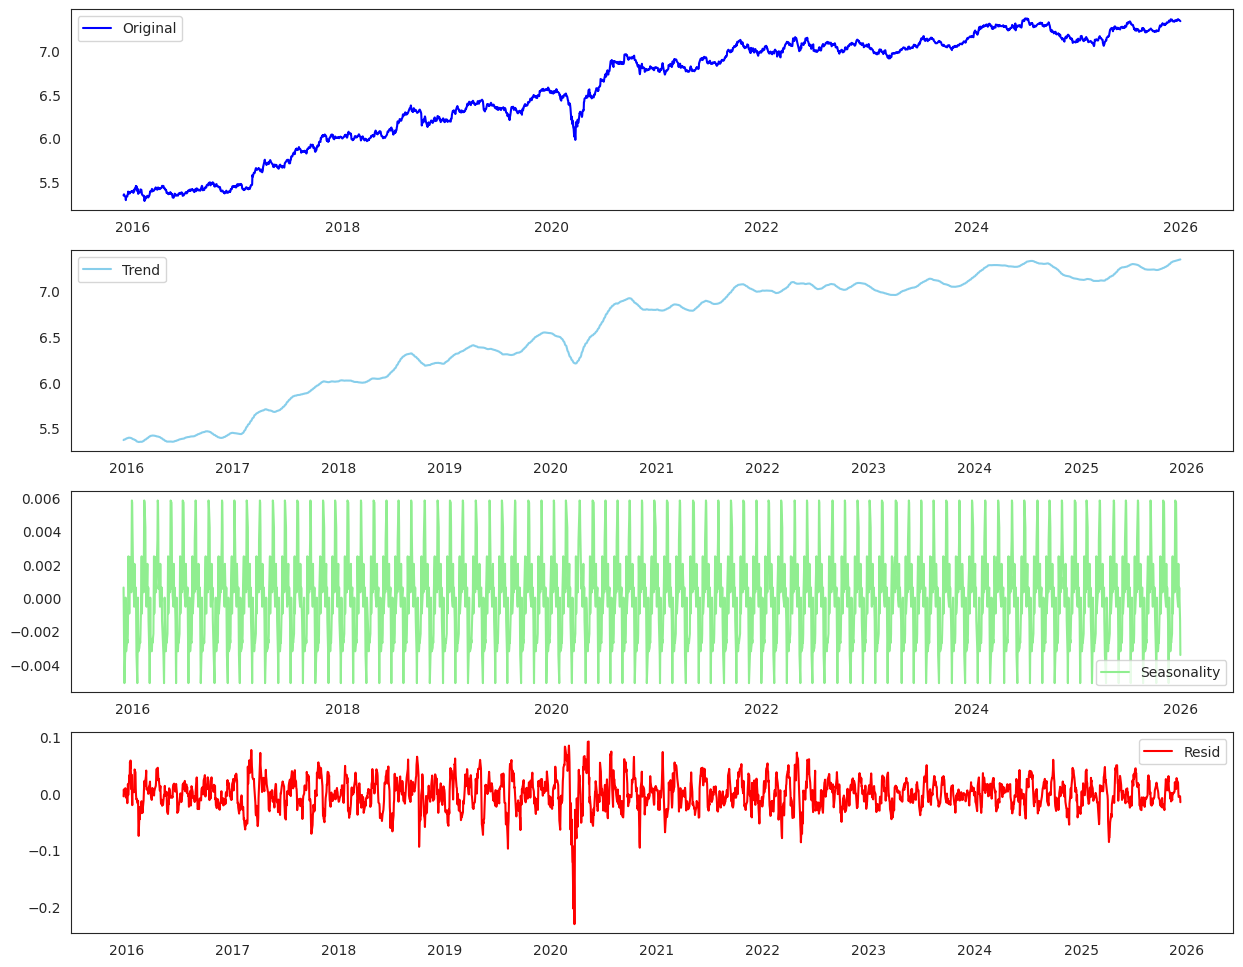

In [80]:
decomposition = seasonal_decompose(dk_logscale['Close'], period=30)

# Extract the components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

figure=plt.figure(figsize=(15,12))
plt.subplot(411)
plt.plot(dk_logscale['Close'], color='blue',label = 'Original')
plt.legend(loc = 'best')

plt.subplot(412)
plt.plot(trend, color='Skyblue',label = 'Trend')
plt.legend(loc = 'best')

plt.subplot(413)
plt.plot(seasonal,color='Lightgreen', label = 'Seasonality')
plt.legend(loc = 'best')

plt.subplot(414)
plt.plot(residual, color ='Red',label = 'Resid')
plt.legend(loc = 'best')

plt.tight_layout

Result of Dickey-Fuller Test::
Test Statistics              -1.329339e+01
p-value                       7.286770e-25
#lag Used                     2.700000e+01
Number of Observation Used    2.435000e+03
Critical Value (1%)          -3.433038e+00
Critical Value (5%)          -2.862728e+00
Critical Value (10%)         -2.567402e+00
dtype: float64
Reject Ho - Time Series is Stationary


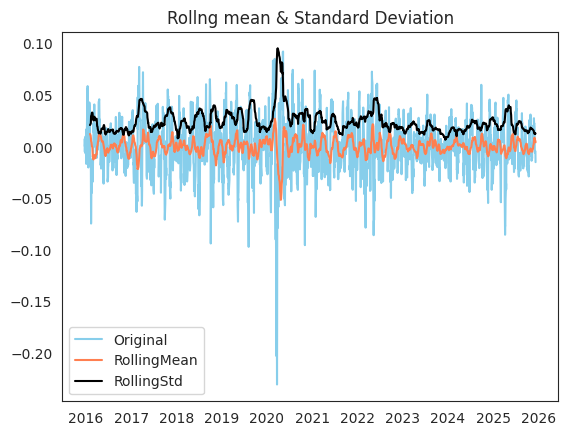

In [81]:
decomposedlogData = residual
decomposedlogData.dropna(inplace=True)
text_stationarity(decomposedlogData)

In [82]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [83]:
lag_acf = acf(ReliancelogDiffShifting['Close'], nlags = 30)
lag_pacf = pacf(ReliancelogDiffShifting['Close'], nlags = 30 , method = 'ols')

In [84]:
np.round(lag_acf,2),np.round(lag_pacf,2)

(array([ 1.  , -0.02,  0.04, -0.01, -0.03,  0.02, -0.03,  0.05, -0.03,
         0.01,  0.05, -0.06,  0.03,  0.01,  0.02, -0.  , -0.02, -0.02,
        -0.05,  0.01, -0.  , -0.03,  0.02,  0.01, -0.01, -0.02,  0.03,
         0.03, -0.02, -0.03, -0.02]),
 array([ 1.  , -0.02,  0.04, -0.  , -0.04,  0.02, -0.02,  0.04, -0.03,
         0.01,  0.05, -0.05,  0.02,  0.02,  0.01, -0.  , -0.01, -0.02,
        -0.04,  0.01,  0.  , -0.03,  0.02,  0.02, -0.01, -0.01,  0.03,
         0.03, -0.02, -0.04, -0.02]))

In [85]:

import statsmodels.api as sm

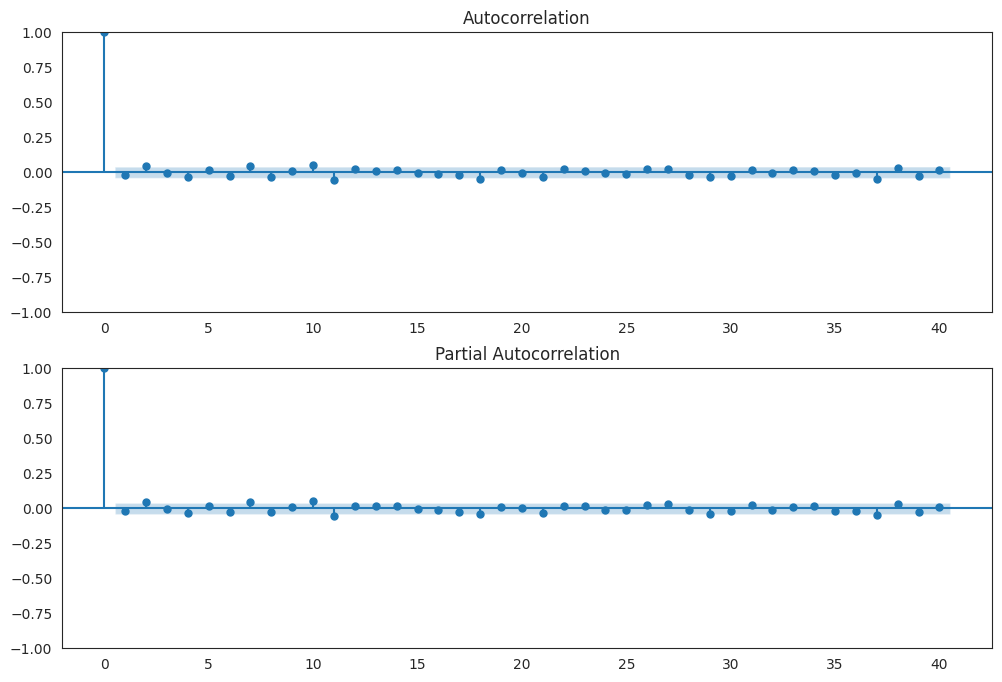

In [86]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ReliancelogDiffShifting['Close'],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ReliancelogDiffShifting['Close'],lags=40,ax=ax2)

# Model Building: Nonstationary data

In [87]:
model=df.copy()
model.head()
model.shape

(2493, 6)

In [88]:
#Splitting the data
Train = model['Close'].head(1745)
Test = model['Close'].tail(748)

In [89]:
Train.head, Test.head()

(<bound method NDFrame.head of Ticker  RELIANCE.NS
 0        209.295013
 1        211.906067
 2        211.743515
 3        209.197495
 4        206.293930
 ...             ...
 1740    1177.008057
 1741    1171.187744
 1742    1186.571655
 1743    1196.843018
 1744    1179.815552
 
 [1745 rows x 1 columns]>,
 Ticker  RELIANCE.NS
 1745    1176.756958
 1746    1142.245850
 1747    1152.220215
 1748    1161.646973
 1749    1161.532837)

In [90]:
def RMSE_Value(forecast, actual):

    rmse_val = np.mean((forecast - actual)**2)**.5
    return(rmse_val)

In [91]:
def MAPE_Value(forecast, actual):
    mape_val = np.mean(np.abs(forecast - actual)/np.abs(actual))

    return(mape_val)

In [92]:



Train= Train.astype('float')
ses_model = SimpleExpSmoothing(Train).fit(smoothing_level=0.8)
pred_ses = ses_model.predict(start = Test.index[0],end = Test.index[-1])
#MAPE value
MAPE_ses_model=MAPE_Value(pred_ses,Test)
print("MAPE_ses_model:",MAPE_ses_model)

#RMSE Value
rmse_ses_model = RMSE_Value(pred_ses,Test)
print("rmse_ses_model:",rmse_ses_model)


MAPE_ses_model: nan
rmse_ses_model: nan


/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning:

Model has no free parameters to estimate. Set optimized=False to suppress this warning



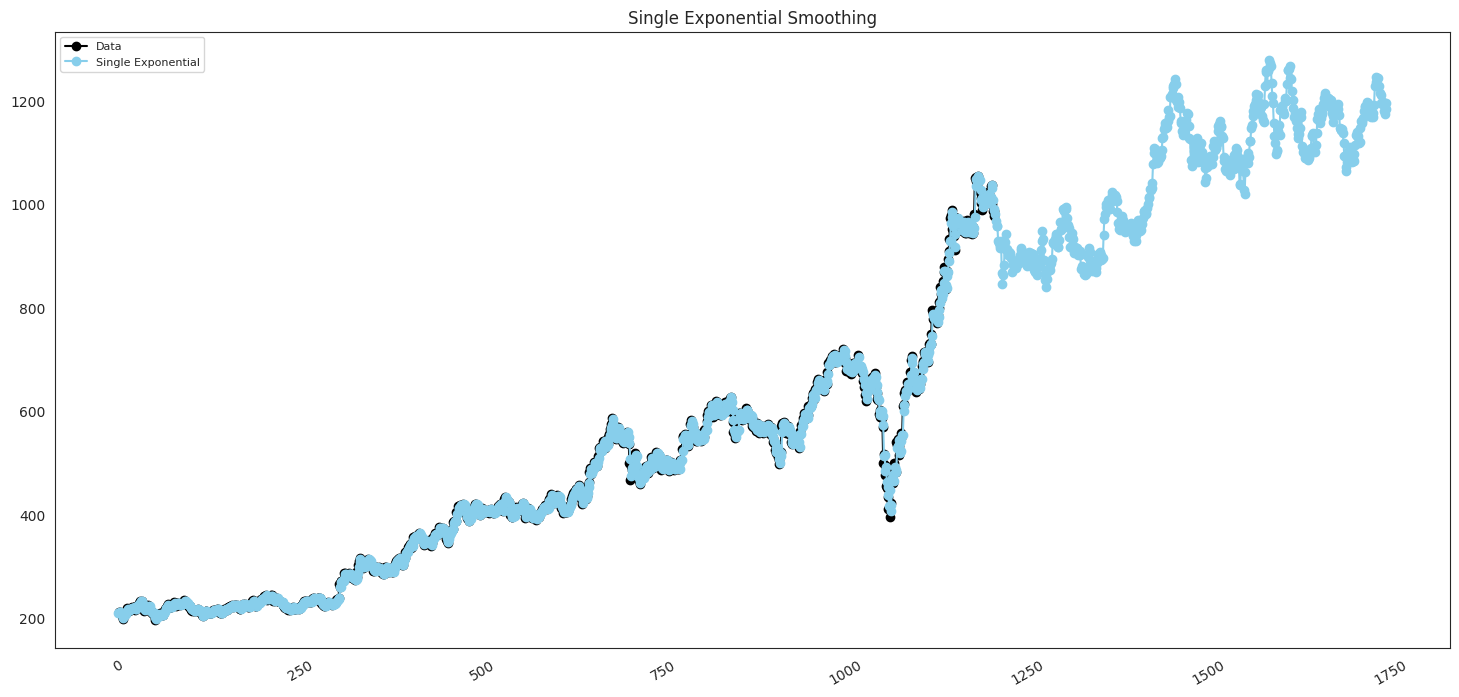

In [93]:
data_SE = model[1:1206]["Close"]
plot1 = SimpleExpSmoothing(Train).fit(smoothing_level=0.8, optimized=False)
plt.figure(figsize=(18,8))
plt.plot(data_SE, marker="o", color="black", label='Data')
plt.xticks(rotation=30)
plt.plot(plot1.fittedvalues, marker="o", color="skyblue",label='Single Exponential')
plt.title('Single Exponential Smoothing')
plt.legend(loc='upper left', fontsize=8)

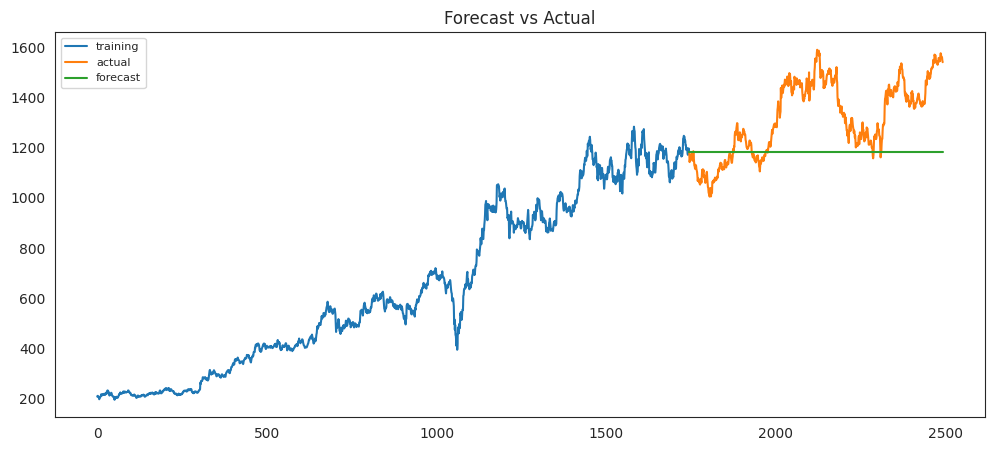

In [94]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train, label='training')
plt.plot(Test, label='actual')
plt.plot(pred_ses, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Holt method

In [95]:
hw_model = Holt(Train).fit(smoothing_level=0.8, smoothing_slope=0.2)
pred_hw = hw_model.predict(start = Test.index[0],end = Test.index[-1])
#MAPE value
MAPE_hw_model= MAPE_Value(pred_hw,Test)
print("MAPE_hw_model:",MAPE_hw_model)

#RMSE Value
rmse_hw_model = RMSE_Value(pred_hw,Test)
print("rmse_hw_model:",rmse_hw_model)

MAPE_hw_model: nan
rmse_hw_model: nan


/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning:

Model has no free parameters to estimate. Set optimized=False to suppress this warning



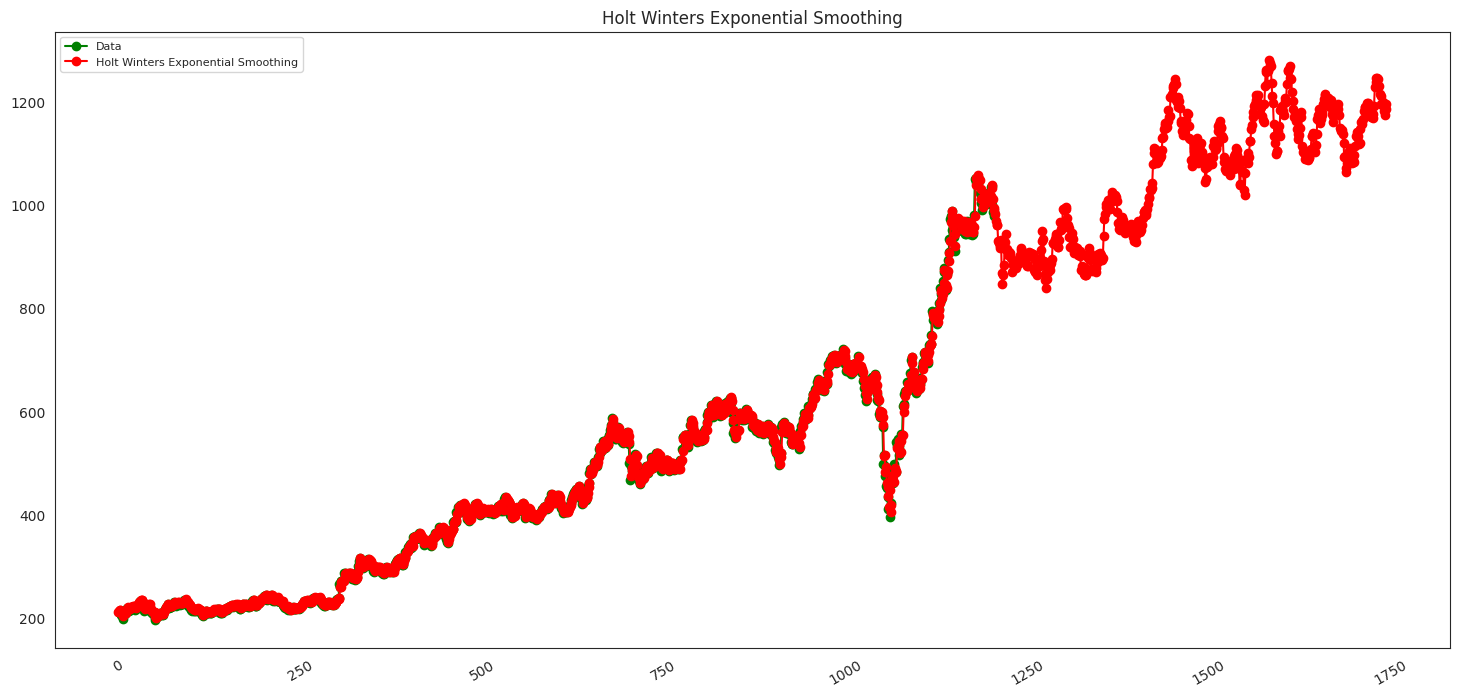

In [96]:
plot2 = Holt(Train, exponential=True).fit(smoothing_level=0.8)
plt.figure(figsize=(18,8))
plt.plot(data_SE, marker="o", color="green", label='Data')
plt.xticks(rotation=30)
plt.plot(plot2.fittedvalues, marker="o", color="red",label = "Holt Winters Exponential Smoothing")
plt.title('Holt Winters Exponential Smoothing')
plt.legend(loc='upper left', fontsize=8)

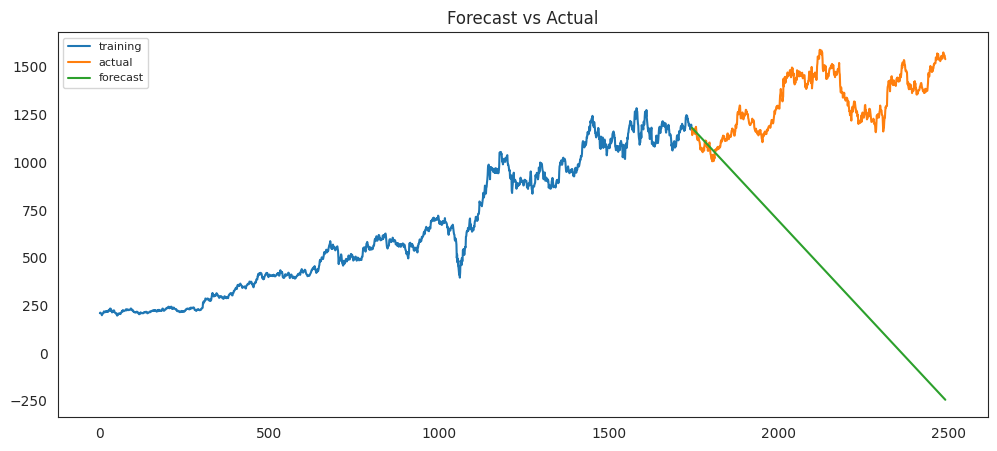

In [97]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train, label='training')
plt.plot(Test, label='actual')
plt.plot(pred_hw, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()


Holts winter exponential smoothing with additive seasonality and additive trend

In [98]:
hwe_model_add_add = ExponentialSmoothing(Train,seasonal="add",trend="add",seasonal_periods=12).fit() #add the trend to the model
pred_hwe_add_add = hwe_model_add_add.predict(start = Test.index[0],end = Test.index[-1])
#mape value
MAPE_hwe_add_add_model=MAPE_Value(pred_hwe_add_add,Test)
print("MAPE_hwe_add_add_model:",MAPE_hwe_add_add_model)

#RMSE value
rmse_hwe_add_add_model = RMSE_Value(pred_hwe_add_add,Test)
print("rmse_hwe_add_add_model:",rmse_hwe_add_add_model)

MAPE_hwe_add_add_model: nan
rmse_hwe_add_add_model: nan


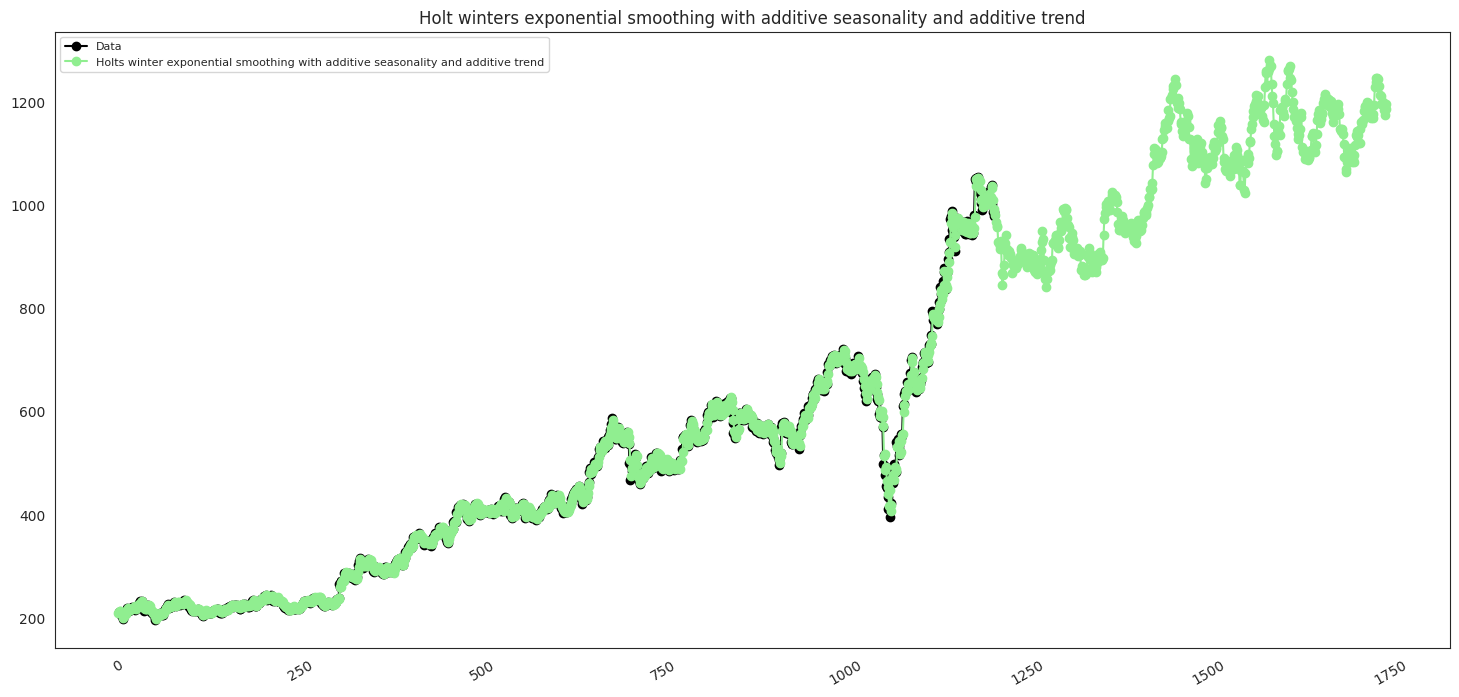

In [99]:
#Plot
plot3 = ExponentialSmoothing(Train,seasonal="add",trend="add",seasonal_periods=12).fit(smoothing_level=0.8)
plt.figure(figsize=(18,8))
plt.plot(data_SE, marker="o", color="black",label="Data")
plt.xticks(rotation=30)
plt.plot(plot3.fittedvalues, marker="o", color="lightgreen",label="Holts winter exponential smoothing with additive seasonality and additive trend")
plt.title('Holt winters exponential smoothing with additive seasonality and additive trend')
plt.legend(loc='upper left', fontsize=8)

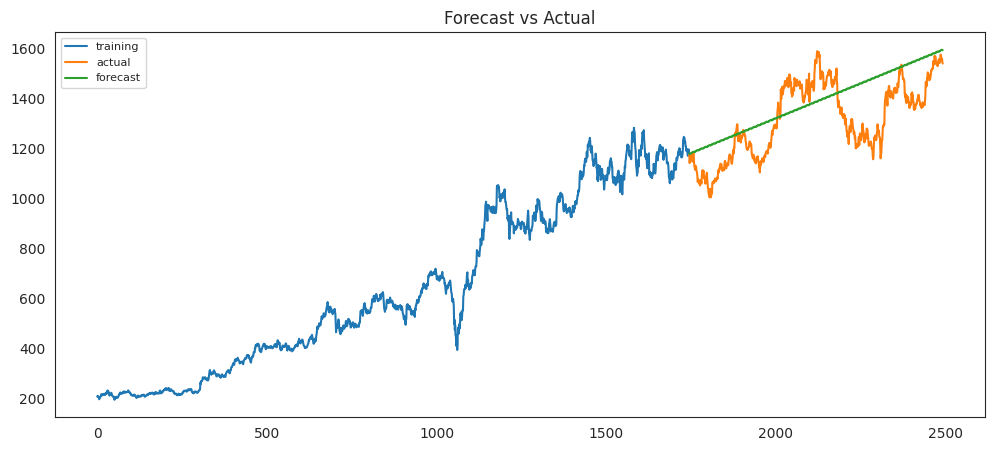

In [100]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train, label='training')
plt.plot(Test, label='actual')
plt.plot(pred_hwe_add_add, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Holts winter exponential smoothing with multiplicative seasonality and additive trend

In [101]:
#MAPE value
hwe_model_mul_add = ExponentialSmoothing(Train,seasonal="mul",trend="add",seasonal_periods=12).fit()
pred_hwe_mul_add = hwe_model_mul_add.predict(start = Test.index[0],end = Test.index[-1])
#MAPE Value
MAPE_hwe_model_mul_add_model=MAPE_Value(pred_hwe_mul_add,Test)
print("MAPE_hwe_model_mul_add_model:",MAPE_hwe_model_mul_add_model)

#RMSE value
rmse_hwe_model_mul_add_model = RMSE_Value(pred_hwe_mul_add,Test)
print("rmse_hwe_model_mul_add_model:",rmse_hwe_model_mul_add_model)

MAPE_hwe_model_mul_add_model: nan
rmse_hwe_model_mul_add_model: nan


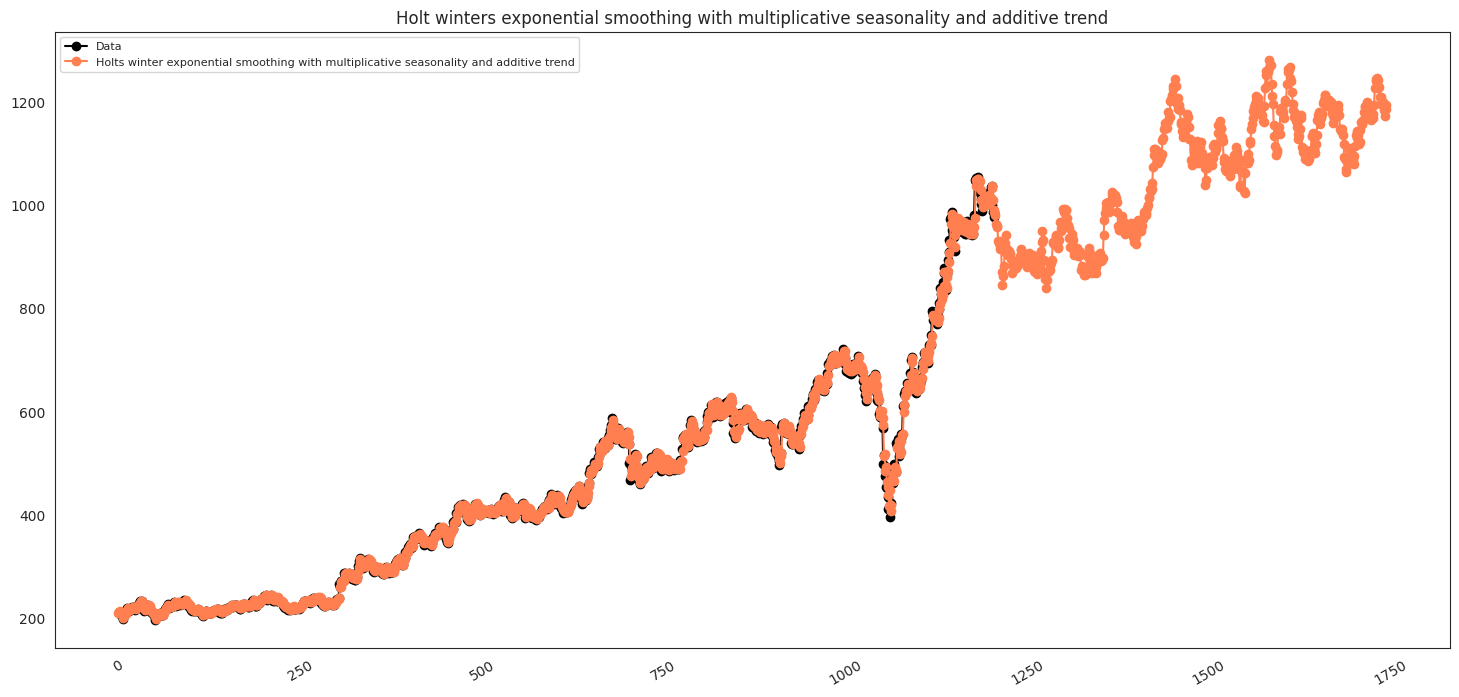

In [102]:
#Plot
plot4 = ExponentialSmoothing(Train, seasonal="mul",trend="add",seasonal_periods=12).fit(smoothing_level=0.8)
plt.figure(figsize=(18,8))
plt.plot(data_SE, marker="o", color="black",label="Data")
plt.xticks(rotation=30)
plt.plot(plot4.fittedvalues, marker="o", color="coral",label="Holts winter exponential smoothing with multiplicative seasonality and additive trend")
plt.title('Holt winters exponential smoothing with multiplicative seasonality and additive trend')
plt.legend(loc='upper left', fontsize=8)

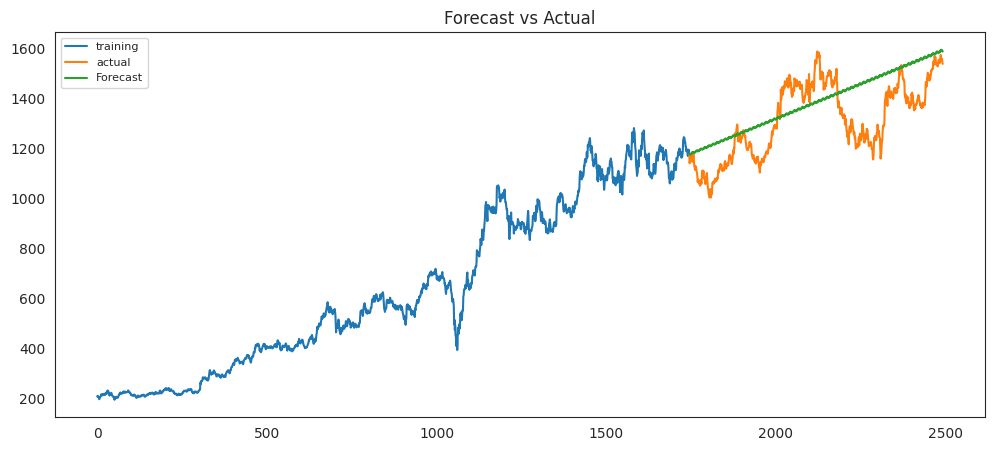

In [103]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train, label='training')
plt.plot(Test, label='actual')
plt.plot(pred_hwe_mul_add, label='Forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Holts winter exponential smoothing with multiplicative seasonality and multiplicative trend

In [104]:
hwe_model_mul_mul = ExponentialSmoothing(Train,seasonal="mul",trend="mul",seasonal_periods=12).fit()
pred_hwe_mul_mul = hwe_model_mul_mul.predict(start = Test.index[0],end = Test.index[-1])
#MAPE Value
MAPE_hwe_model_mul_mul_model=MAPE_Value(pred_hwe_mul_mul,Test)
print("MAPE_hwe_model_mul_mul_model:",MAPE_hwe_model_mul_mul_model)

#RMSE value
rmse_hwe_model_mul_mul_model = RMSE_Value(pred_hwe_mul_mul,Test)
print("rmse_hwe_model_mul_mul_model:",rmse_hwe_model_mul_mul_model)

MAPE_hwe_model_mul_mul_model: nan
rmse_hwe_model_mul_mul_model: nan


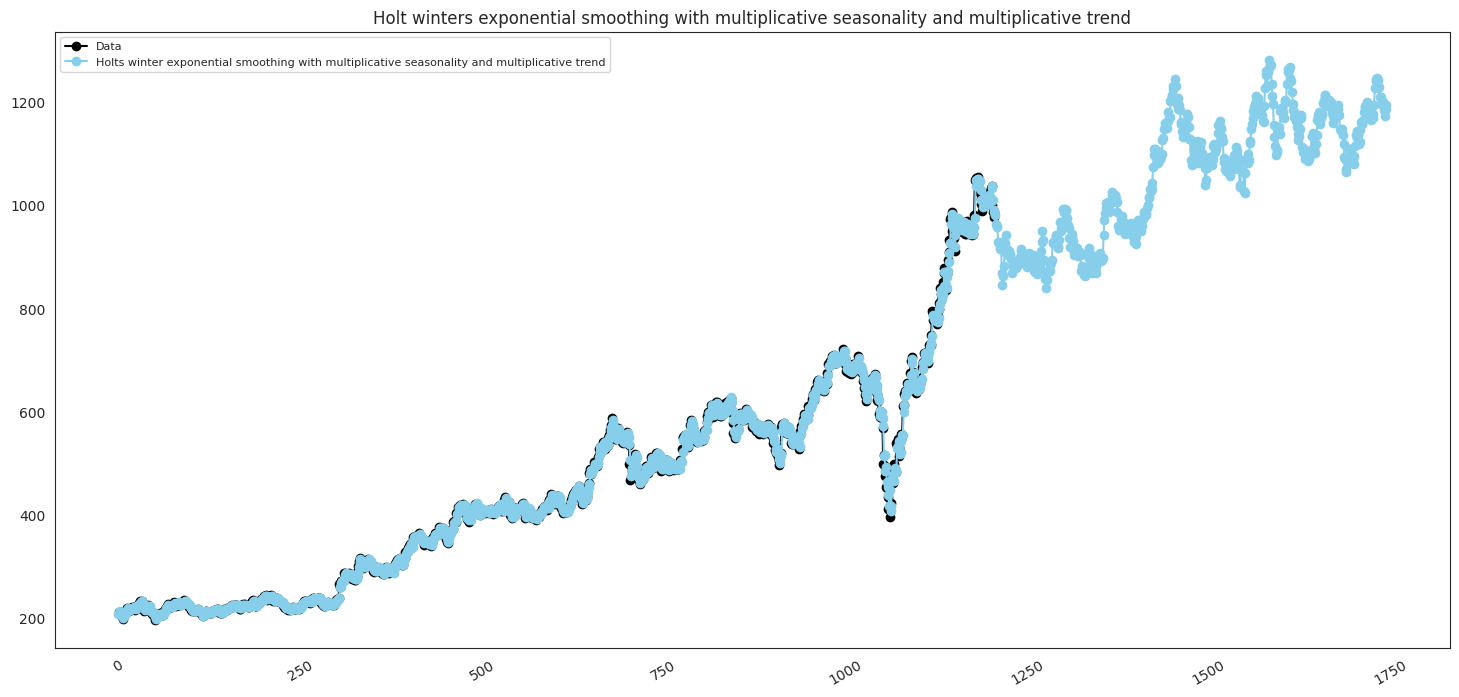

In [105]:
#Plot
plot5 = ExponentialSmoothing(Train, seasonal="mul",trend="mul",seasonal_periods=12).fit(smoothing_level=0.8)
plt.figure(figsize=(18,8))
plt.plot(data_SE, marker="o",  color="black",label="Data")
plt.xticks(rotation=30)
plt.plot(plot5.fittedvalues, marker="o", color="skyblue",label="Holts winter exponential smoothing with multiplicative seasonality and multiplicative trend")
plt.title('Holt winters exponential smoothing with multiplicative seasonality and multiplicative trend')
plt.legend(loc='upper left', fontsize=8)

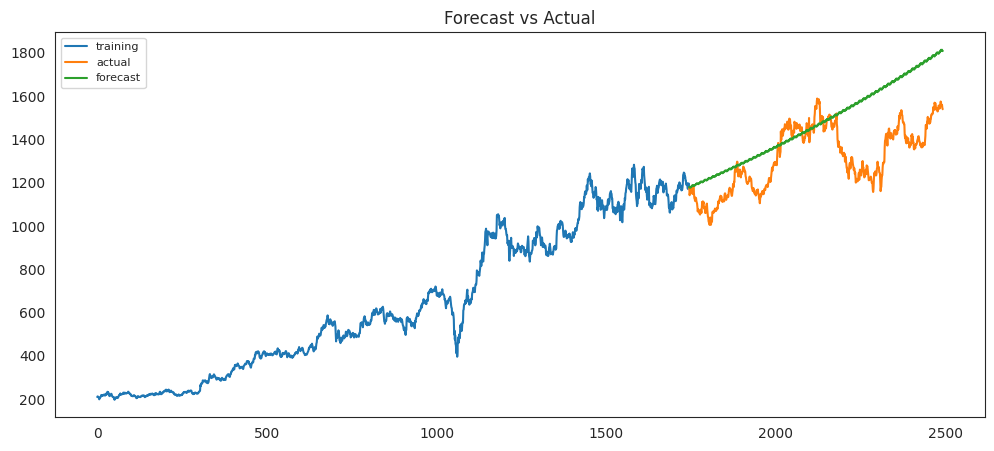

In [106]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train, label='training')
plt.plot(Test, label='actual')
plt.plot(pred_hwe_mul_mul, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Model Based Forecasting
Linear , Exponential and Quadratic Models of forecasting:

In [107]:
datamodel=Reliance2.copy()
columns_to_drop = ['Open', 'High', 'Low', 'Volume', 'Date']
datamodel = datamodel.drop(columns_to_drop, axis=1)
datamodel.head()

Price,Close,Close_boxcox,logClose,sqr_Close,Rec_Close
Ticker,RELIANCE.NS,,,,
0,209.295013,58.719520,5.343745,14.467032,0.004778
1,211.906067,59.243715,5.356143,14.556994,0.004719
2,211.743515,59.211138,5.355376,14.551409,0.004723
3,209.197495,58.699904,5.343279,14.463661,0.004780
4,206.293930,58.114592,5.329302,14.362936,0.004847


In [108]:
datamodel.shape

(2493, 5)

In [109]:
datamodel["t"] = np.arange(1, len(datamodel) + 1)
datamodel["t_squared"]=datamodel["t"]*datamodel["t"]
datamodel.head()

Price,Close,Close_boxcox,logClose,sqr_Close,Rec_Close,t,t_squared
Ticker,RELIANCE.NS,,,,,,
0,209.295013,58.719520,5.343745,14.467032,0.004778,1,1
1,211.906067,59.243715,5.356143,14.556994,0.004719,2,4
2,211.743515,59.211138,5.355376,14.551409,0.004723,3,9
3,209.197495,58.699904,5.343279,14.463661,0.004780,4,16
4,206.293930,58.114592,5.329302,14.362936,0.004847,5,25


In [110]:
#Splitting data into Train and Test
Train_m = datamodel.head(1745)
Test_m = datamodel.tail(748)

In [111]:
Train_m.head()

Price,Close,Close_boxcox,logClose,sqr_Close,Rec_Close,t,t_squared
Ticker,RELIANCE.NS,,,,,,
0,209.295013,58.719520,5.343745,14.467032,0.004778,1,1
1,211.906067,59.243715,5.356143,14.556994,0.004719,2,4
2,211.743515,59.211138,5.355376,14.551409,0.004723,3,9
3,209.197495,58.699904,5.343279,14.463661,0.004780,4,16
4,206.293930,58.114592,5.329302,14.362936,0.004847,5,25


In [112]:
Test_m.head()

Price,Close,Close_boxcox,logClose,sqr_Close,Rec_Close,t,t_squared
Ticker,RELIANCE.NS,,,,,,
1745,1176.756958,199.981065,7.070518,34.303891,0.000850,1746,3048516
1746,1142.245850,195.828598,7.040752,33.797128,0.000875,1747,3052009
1747,1152.220215,197.032562,7.049446,33.944369,0.000868,1748,3055504
1748,1161.646973,198.167554,7.057594,34.082943,0.000861,1749,3059001
1749,1161.532837,198.153828,7.057496,34.081268,0.000861,1750,3062500


Linear Model

In [113]:
import statsmodels.formula.api as smf

In [114]:
import statsmodels.formula.api as smf
linear_model = smf.ols('Close~t',data=Train_m).fit()
pred_linear = pd.Series(linear_model.predict(pd.DataFrame(Test_m['t'])))
#MAPE value
MAPE_linear_model = MAPE_Value(pred_linear,Test_m['Close'])
print("MAPE_linear_model:",MAPE_linear_model)
rmse_linear_model = RMSE_Value(pred_linear,Test_m['Close'])
print("rmse_linear_model:",rmse_linear_model)

print("**********************************")
#RMSE value


linear_model.summary()

MAPE_linear_model: nan
rmse_linear_model: nan
**********************************


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                 3.079e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        20:23:18   Log-Likelihood:                -10058.
No. Observations:                1745   AIC:                         2.012e+04
Df Residuals:                    1743   BIC:                         2.013e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     80.2132      3.695     21.710      0.000      72.967      87.460
t              0.6433      0.004    175.481      0.000       0.636       0.650
==============================================================================
Omnibus:                      115.481   Durbin-Watson:                   0.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              348.870
Skew:                          -0.308   Prob(JB):                     1.75e-76
Kurtosis:                       5.102   Cond. No.                     2.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

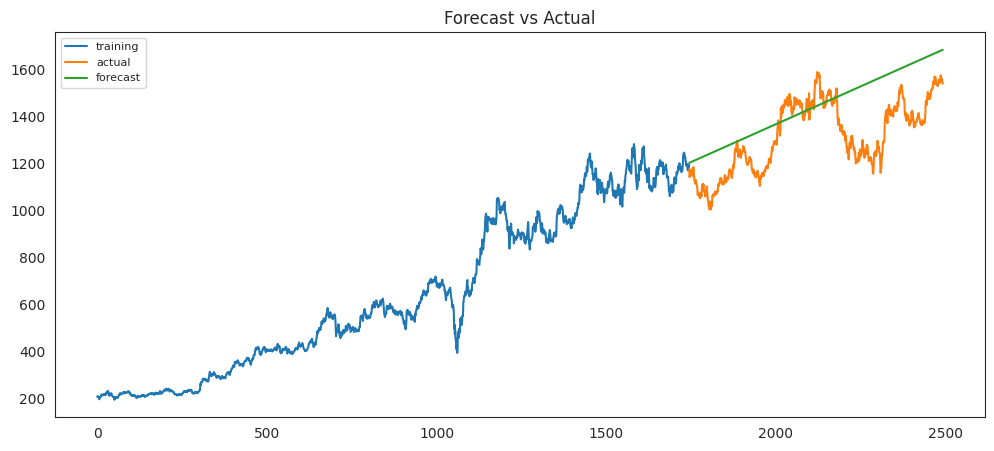

In [115]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train_m["Close"], label='training')
plt.plot(Test_m["Close"], label='actual')
plt.plot(pred_linear, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

Quadratic Model

In [116]:
Exp = smf.ols('logClose~t',data=Train_m).fit()
pred_Exp = pd.Series(Exp.predict(pd.DataFrame(Test_m['t'])))

#RMSE value
rmse_Exp_model = RMSE_Value(np.exp(pred_Exp),Test_m['Close'])
print("rmse_Exp_model:",rmse_Exp_model)

#MAPE Value
MAPE_Exp_model = MAPE_Value(np.exp(pred_Exp),Test_m['Close'])
print("MAPE_Exp_model:",MAPE_Exp_model)
print("******************************************")
Exp.summary()

rmse_Exp_model: nan
MAPE_Exp_model: nan
******************************************


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               logClose   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 3.977e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        20:23:18   Log-Likelihood:                 1247.6
No. Observations:                1745   AIC:                            -2491.
Df Residuals:                    1743   BIC:                            -2480.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3303      0.006    939.527      0.000       5.319       5.341
t              0.0011   5.63e-06    199.428      0.000       0.001       0.001
==============================================================================
Omnibus:                       50.418   Durbin-Watson:                   0.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.456
Skew:                          -0.348   Prob(JB):                     4.52e-14
Kurtosis:                       3.600   Cond. No.                     2.02e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.02e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

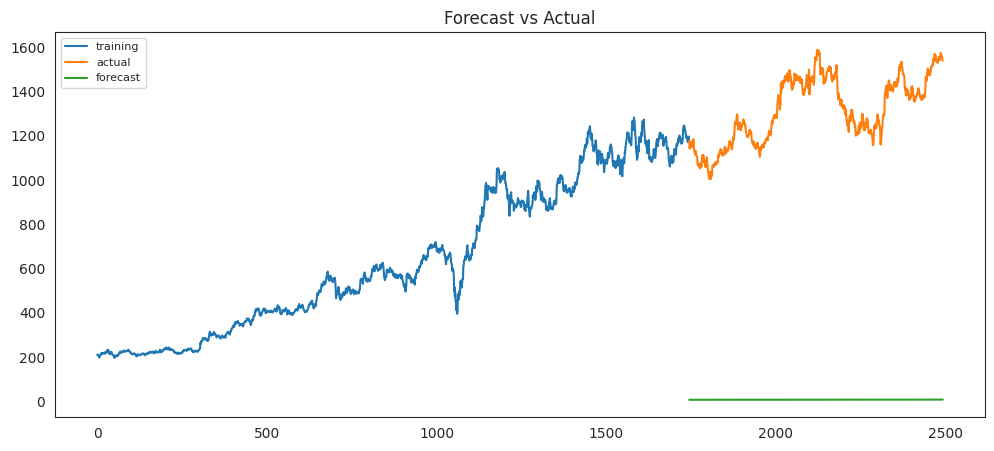

In [117]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train_m["Close"], label='training')
plt.plot(Test_m["Close"], label='actual')
plt.plot(pred_Exp, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [118]:
Quad = smf.ols('Close~t+t_squared',data=Train_m).fit()
pred_Quad = pd.Series(Quad.predict(Test_m[["t","t_squared"]]))

#RMSE VALUE
rmse_Quad_model = RMSE_Value(pred_Quad,Test_m['Close'])
print("rmse_Quad_model:",rmse_Quad_model)

#MAPE Value
MAPE_Quad_model = MAPE_Value(pred_Quad,Test_m['Close'])
print("MAPE_Quad_model:",MAPE_Quad_model)
print("*********************************************")
Quad.summary()

rmse_Quad_model: nan
MAPE_Quad_model: nan
*********************************************


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Close   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                 2.006e+04
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        20:23:18   Log-Likelihood:                -9837.7
No. Observations:                1745   AIC:                         1.968e+04
Df Residuals:                    1742   BIC:                         1.970e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    161.8008      4.889     33.092      0.000     152.211     171.390
t              0.3631      0.013     28.071      0.000       0.338       0.388
t_squared      0.0002   7.17e-06     22.375      0.000       0.000       0.000
==============================================================================
Omnibus:                      136.460   Durbin-Watson:                   0.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              741.005
Skew:                          -0.050   Prob(JB):                    1.24e-161
Kurtosis:                       6.191   Cond. No.                     4.09e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.09e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

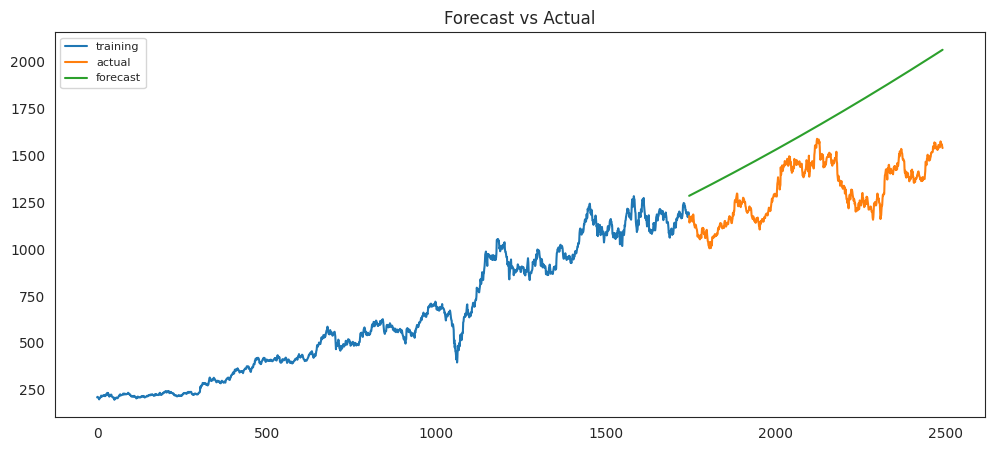

In [119]:
# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(Train_m["Close"], label='training')
plt.plot(Test_m["Close"], label='actual')
plt.plot(pred_Quad, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

ARIMA MODEL :NON STATIONARY DATA

In [120]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import warnings

In [121]:
ari=df.copy()
ari=ari.set_index('Date')
ari.head()


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-12-01,209.295013,212.090229,208.287433,208.883311,12981379
2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628
2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395
2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688
2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909


In [122]:
print(ari.shape)
train=df.iloc[:-748]
test=df.iloc[-748:]
print(train.shape, test.shape)

(2493, 5)
(1745, 6) (748, 6)


In [123]:
fit=auto_arima(ari.Close,trace=True,suppress_warnings=True)
fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=20306.763, Time=2.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20302.703, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20304.693, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20304.693, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20304.219, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=20306.699, Time=0.20 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.863 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2493
Model:               SARIMAX(0, 1, 0)   Log Likelihood              -10149.352
Date:                Sun, 04 Jan 2026   AIC                          20302.703
Time:                        20:23:21   BIC                          20314.345
Sample:                             0   HQIC                         20306.930
                               - 2493                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5339      0.285      1.876      0.061      -0.024       1.092
sigma2       201.8793      2.829     71.350      0.000     196.334     207.425
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              3959.40
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               7.65   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [124]:
model=ARIMA(train.Close,order=(2,1,2))
result=model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            RELIANCE.NS   No. Observations:                 1745
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -6938.806
Date:                Sun, 04 Jan 2026   AIC                          13887.612
Time:                        20:23:22   BIC                          13914.932
Sample:                             0   HQIC                         13897.713
                               - 1745                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1626      0.017      9.297      0.000       0.128       0.197
ar.L2         -0.9478      0.017    -54.703      0.000      -0.982      -0.914
ma.L1         -0.1375      0.015     -9.467      0.000      -0.166      -0.109
ma.L2          0.9648      0.014     66.617      0.000       0.936       0.993
sigma2       167.2441      2.810     59.513      0.000     161.736     172.752
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):              2907.06
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):              17.39   Skew:                             0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [125]:
start = len(train)
end = len(train)+len(test)-1
pred_arima = result.predict(start=start,end=end)
print(pred_arima)

1745    1177.021143
1746    1175.429546
1747    1177.819376
1748    1179.716624
1749    1177.759980
           ...     
2488    1177.613269
2489    1177.613269
2490    1177.613269
2491    1177.613269
2492    1177.613269
Name: predicted_mean, Length: 748, dtype: float64


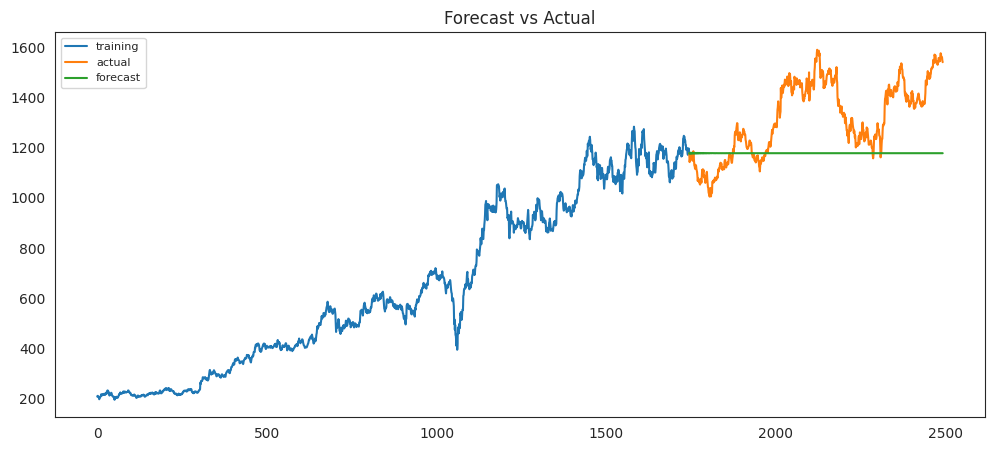

In [126]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train.Close, label='training')
plt.plot(test.Close, label='actual')
plt.plot(pred_arima, label='forecast')

plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [127]:
#RMSE value
RMSE_ARIMA = RMSE_Value(pred_arima,test.Close)
print("RMSE_ARIMA:",RMSE_ARIMA)
#MAPE Value
MAPE_ARIMA = MAPE_Value(pred_arima, test.Close)*100
print("MAPE_ARIMA:",MAPE_ARIMA)

RMSE_ARIMA: nan
MAPE_ARIMA: nan


Auto Regressor (AR) model

In [128]:
model_ar = AutoReg(train.Close,lags = 6).fit()
print(model_ar.summary())

                            AutoReg Model Results                             
Dep. Variable:            RELIANCE.NS   No. Observations:                 1745
Model:                     AutoReg(6)   Log Likelihood               -6923.545
Method:               Conditional MLE   S.D. of innovations             12.967
Date:                Sun, 04 Jan 2026   AIC                          13863.090
Time:                        20:23:23   BIC                          13906.779
Sample:                             6   HQIC                         13879.245
                                 1745                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.8916      0.677      1.318      0.188      -0.435       2.218
RELIANCE.NS.L1     1.0193      0.024     42.503      0.000       0.972       1.066
RELIANCE.NS.L2     0.0050      0.034

In [129]:
pred_ar = model_ar.predict(start=start,end=end,dynamic = False)
print(pred_ar)

1745    1179.006413
1746    1177.690039
1747    1178.805779
1748    1180.035074
1749    1179.905088
           ...     
2488    1354.355452
2489    1354.549510
2490    1354.743468
2491    1354.937327
2492    1355.131085
Length: 748, dtype: float64


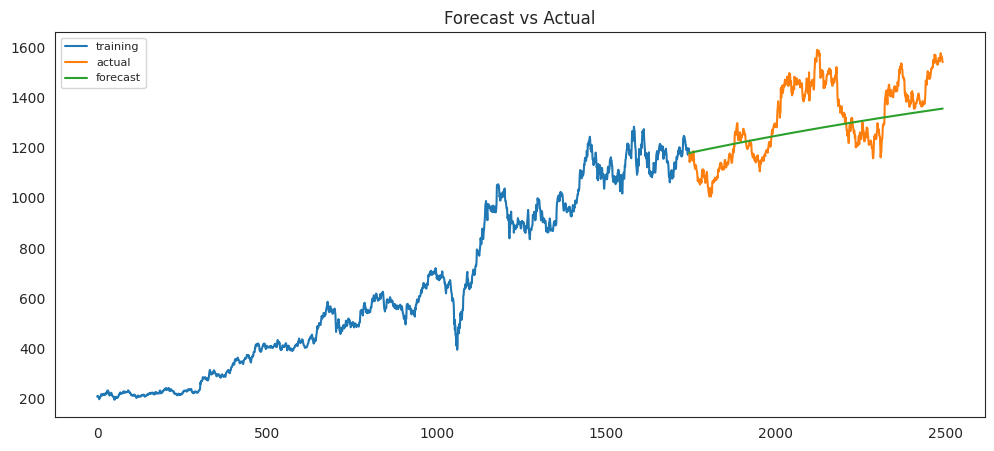

In [130]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train.Close, label='training')
plt.plot(test.Close, label='actual')
plt.plot(pred_ar, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [131]:
RMSE_AR = RMSE_Value(pred_ar,test.Close)
print("RMSE_AR",RMSE_AR)
#MAPE Value
MAPE_AR = MAPE_Value(pred_ar,test.Close)*100
print("MAPE_AR:",MAPE_AR)

RMSE_AR nan
MAPE_AR: nan


Moving Average (MA) model

In [132]:
model_ma = ARIMA(train.Close,order = (0,1,3))
model_ma = model_ma.fit()
pred_ma = model_ma.predict(start=start,end=end)
print(pred_ma)
model_ma.summary()

1745    1179.111285
1746    1178.211694
1747    1178.936214
1748    1178.936214
1749    1178.936214
           ...     
2488    1178.936214
2489    1178.936214
2490    1178.936214
2491    1178.936214
2492    1178.936214
Name: predicted_mean, Length: 748, dtype: float64


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            RELIANCE.NS   No. Observations:                 1745
Model:                 ARIMA(0, 1, 3)   Log Likelihood               -6944.666
Date:                Sun, 04 Jan 2026   AIC                          13897.332
Time:                        20:23:23   BIC                          13919.188
Sample:                             0   HQIC                         13905.413
                               - 1745                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0189      0.018      1.059      0.290      -0.016       0.054
ma.L2          0.0289      0.016      1.760      0.078      -0.003       0.061
ma.L3         -0.0405      0.016     -2.475      0.013      -0.073      -0.008
sigma2       168.3735      2.840     59.286      0.000     162.807     173.940
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2898.80
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):              17.37   Skew:                             0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

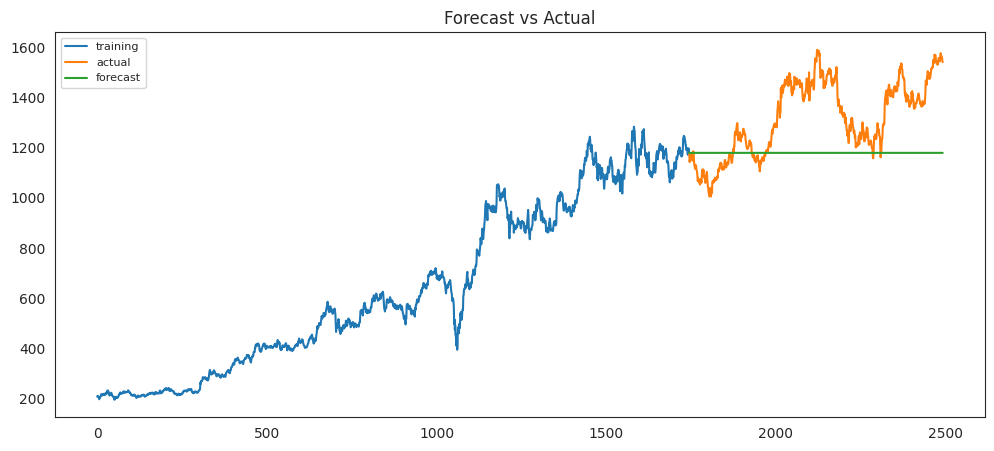

In [133]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train.Close, label='training')
plt.plot(test.Close, label='actual')
plt.plot(pred_ma, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [134]:
#RMSE Value
RMSE_MA = RMSE_Value(pred_ma,test.Close)
print("RMSE_MA:",RMSE_MA)
#MAPE Value
MAPE_MA = MAPE_Value(pred_ma, test.Close)*100#RMSE Value
print("MAPE_MA:",MAPE_MA)

RMSE_MA: nan
MAPE_MA: nan


SARIMAX

In [135]:
#for order(0,2,3)
model_1=sm.tsa.statespace.SARIMAX(ari.Close,order=(0,2,3),seasonal_order=(0,2,3,12))
results_1=model_1.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [136]:
start = len(train)
end = len(train)+len(test)-1
pred_sarimax_1 = results_1.predict(start=start,end=end)
print(pred_sarimax_1)

Date
2022-12-22    1178.460564
2022-12-23    1176.381762
2022-12-26    1137.321964
2022-12-27    1150.942492
2022-12-28    1162.570275
                 ...     
2025-12-24    1564.945398
2025-12-25    1556.644652
2025-12-26    1558.024741
2025-12-29    1558.764756
2025-12-30    1546.246246
Name: predicted_mean, Length: 748, dtype: float64


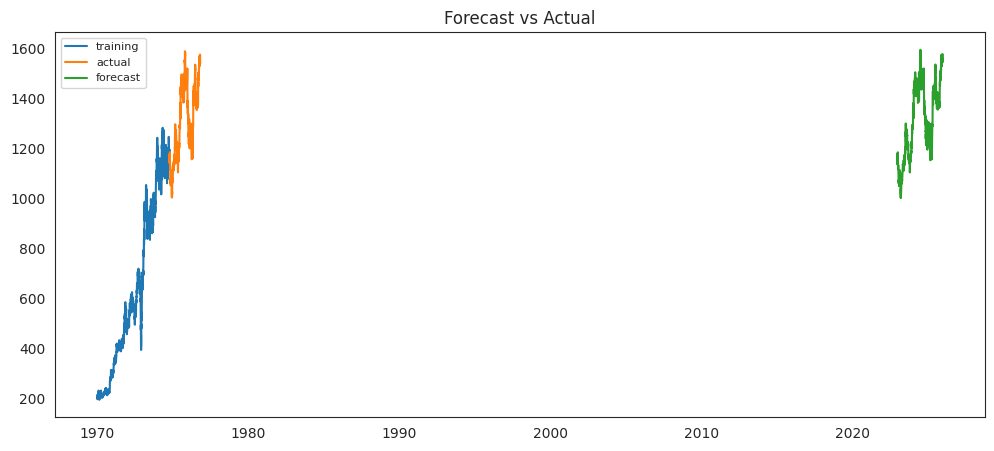

In [137]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train.Close, label='training')
plt.plot(test.Close, label='actual')
plt.plot(pred_sarimax_1, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [138]:
RMSE_SARIMAX_1 = RMSE_Value(pred_sarimax_1.values, test.Close.values)
print("RMSE_SARIMAX_1:", RMSE_SARIMAX_1)

MAPE_SARIMAX_1 = MAPE_Value(pred_sarimax_1.values, test.Close.values)
print("MAPE_SARIMAX_1:", MAPE_SARIMAX_1)


RMSE_SARIMAX_1: 209.27739202744533
MAPE_SARIMAX_1: 0.1318738728764044


Sarimax, diff order

In [139]:
#for order(3,1,4)
model=sm.tsa.statespace.SARIMAX(ari.Close,order=(2,1,2),seasonal_order=(2,1,2,12))
results=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [140]:
start = len(train)
end = len(train)+len(test)-1
pred_sarimax = results.predict(start=start,end=end)
print(pred_sarimax)

Date
2022-12-22    1181.013023
2022-12-23    1176.786471
2022-12-26    1141.784471
2022-12-27    1150.646318
2022-12-28    1164.073172
                 ...     
2025-12-24    1570.776072
2025-12-25    1558.842135
2025-12-26    1559.037723
2025-12-29    1559.564136
2025-12-30    1544.707290
Name: predicted_mean, Length: 748, dtype: float64


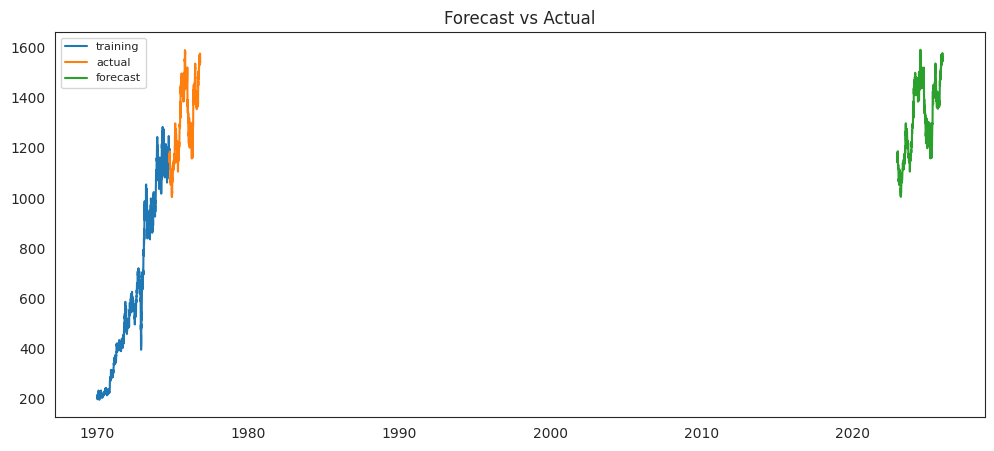

In [141]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train.Close, label='training')
plt.plot(test.Close, label='actual')
plt.plot(pred_sarimax, label='forecast')
plt.title('Forecast vs Actual')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [142]:
#RMSE Value
RMSE_SARIMAX_a = RMSE_Value(pred_sarimax, test.Close)
print("RMSE_SARIMAX_a:",RMSE_SARIMAX_a)

#MAPE Value
MAPE_SARIMAX_a = MAPE_Value(pred_sarimax, test.Close)
print("MAPE_SARIMAX_a:",MAPE_SARIMAX_a)


RMSE_SARIMAX_a: nan
MAPE_SARIMAX_a: nan


LSTM using RNN

In [143]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

from sklearn.preprocessing import StandardScaler


In [144]:
Reliance2 = Reliance1.dropna()
Reliance2.head()


,Date,Close,High,Low,Open,Volume,Year,Month,Daily_Gain
1,2015-12-02,211.906067,212.285267,208.991664,209.370865,7573628,2015,Dec,0.012475
2,2015-12-03,211.743515,214.289551,211.071800,211.245142,11361395,2015,Dec,-0.000767
3,2015-12-04,209.197495,211.526853,208.319935,210.681780,13443688,2015,Dec,-0.012024
4,2015-12-07,206.293930,210.833459,205.795557,209.197484,14483909,2015,Dec,-0.013880
5,2015-12-08,203.877899,206.629779,202.837817,205.611364,7532164,2015,Dec,-0.011712


In [145]:
Close = Reliance2[['Close']]
Close

,Close
1,211.906067
2,211.743515
3,209.197495
4,206.293930
5,203.877899
...,...
2488,1558.199951
2489,1558.199951
2490,1559.199951
2491,1545.599976


<Axes: >

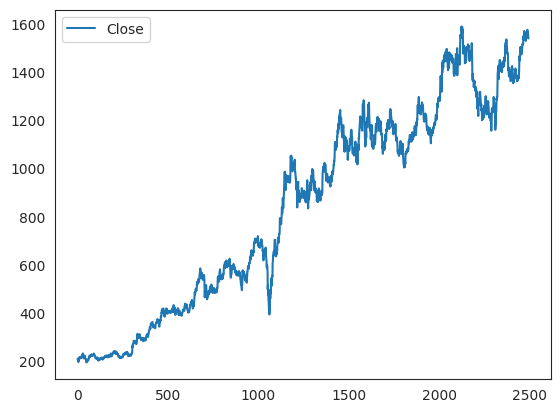

In [146]:
Close.plot()

In [147]:
ds = Close.values
ds

array([[ 211.90606689],
       [ 211.74351501],
       [ 209.19749451],
       ...,
       [1559.19995117],
       [1545.59997559],
       [1539.80004883]])

In [148]:
from sklearn.preprocessing import MinMaxScaler

In [149]:
normalizer = MinMaxScaler(feature_range=(0,1))
ds_scaled = normalizer.fit_transform(np.array(ds).reshape(-1,1))

In [150]:
len(ds_scaled),len(ds)

(2492, 2492)

In [151]:

train_size=int(len(ds_scaled)*0.70)
test_size = len(ds_scaled)-train_size

In [152]:
test_size,train_size

(748, 1744)

In [153]:
ds_train,ds_test = ds_scaled [0:train_size,:] ,ds_scaled[train_size:len(ds_scaled),:1]

In [154]:
len(ds_train),len(ds_test)


(1744, 748)

In [155]:
def create_ds(dataset,step):
    Xtrain ,Ytrain = [],[]
    for i in range(len(dataset)-step-1):
        a = dataset[i:(i+step),0]
        Xtrain.append(a)
        Ytrain.append(dataset[i+step,0])

    return np.array(Xtrain),np.array(Ytrain)


In [156]:
time_stamp = 100
X_train , y_train = create_ds(ds_train,time_stamp)
X_test , y_test = create_ds(ds_test,time_stamp)

In [157]:
X_train.shape , y_train.shape

((1643, 100), (1643,))

In [158]:
X_test.shape , y_test.shape

((647, 100), (647,))

In [159]:
X_train = X_train.reshape(X_train.shape[0] , X_train.shape[1],1)
X_test =  X_test.reshape(X_test.shape[0] , X_test.shape[1],1)

In [160]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

In [161]:
model = Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50,return_sequences=True))
model.add(LSTM(units=50))
model.add(Dense(units=1,activation='linear'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [162]:
model.compile(loss='mean_squared_error',optimizer='adam')
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.0472 - val_loss: 0.0059
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 8.5409e-04 - val_loss: 0.0018
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.4990e-04 - val_loss: 0.0019
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.0890e-04 - val_loss: 0.0016
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.9456e-04 - val_loss: 0.0024
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.4540e-04 - val_loss: 0.0012
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 7.9577e-04 - val_loss: 0.0018
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 7.8661e-04 - val_loss: 0.0014
Epoch 11/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 6.9477e-04 - val_loss: 0.0012
Epoch 12/100
26/26 ━

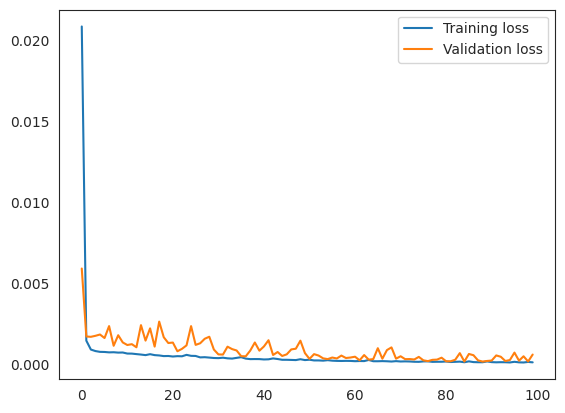

In [163]:
#PLotting loss, it shows that loss has decreased significantly and model trained well
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.legend()

In [164]:
#Predicitng on train and test data
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [165]:
#Inverse transform to get actual value
train_predict = normalizer.inverse_transform(train_predict)
test_predict = normalizer.inverse_transform(test_predict)

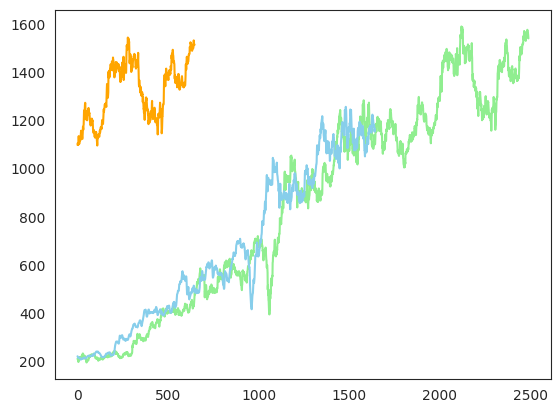

In [166]:
#Comparing using visuals
plt.plot(normalizer.inverse_transform(ds_scaled),color='lightgreen')
plt.plot((train_predict),color='skyblue')
plt.plot((test_predict),color='orange')

In [167]:
type(train_predict)

numpy.ndarray

In [168]:
test = np.vstack((train_predict,test_predict))
test

array([[ 222.15811],
       [ 220.24516],
       [ 218.4855 ],
       ...,
       [1511.6638 ],
       [1511.8236 ],
       [1514.638  ]], dtype=float32)

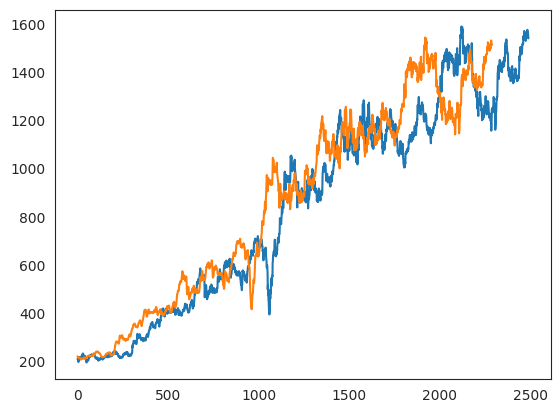

In [169]:
#Combining the predited data to create uniform data visualization
plt.plot(normalizer.inverse_transform(ds_scaled))
plt.plot((test))



In [170]:
len(ds_test)

748

In [171]:
#Getting the last 100 days records
fut_inp = ds_test[417:]
fut_inp

array([[0.94211767],
       [0.92668778],
       [0.90655564],
       [0.90485716],
       [0.90419567],
       [0.89702608],
       [0.91726541],
       [0.91213404],
       [0.91122221],
       [0.91190168],
       [0.9055723 ],
       [0.9100243 ],
       [0.92164589],
       [0.92697387],
       [0.92411315],
       [0.92738503],
       [0.93024575],
       [0.95043152],
       [0.91495899],
       [0.90655564],
       [0.86518305],
       [0.85055778],
       [0.83925805],
       [0.85829946],
       [0.84202936],
       [0.83949049],
       [0.84024139],
       [0.84054536],
       [0.82016299],
       [0.82735045],
       [0.82903114],
       [0.83108723],
       [0.83816742],
       [0.81968021],
       [0.81622952],
       [0.81714143],
       [0.80859504],
       [0.81324364],
       [0.81728439],
       [0.82007358],
       [0.8115988 ],
       [0.81631892],
       [0.7902152 ],
       [0.79246798],
       [0.80680716],
       [0.79271831],
       [0.77705597],
       [0.769

In [172]:
fut_inp = fut_inp.reshape(1,-1)
tmp_inp = list(fut_inp)
fut_inp.shape

(1, 331)

In [173]:

#Creating list of the last 100 data
tmp_inp = tmp_inp[0].tolist()



In [174]:
len(tmp_inp)




331

In [177]:
#Predicting next 60 days price suing the current data
#It will predict in sliding window manner (algorithm) with stride 1
lst_output = []
n_steps = 100
i = 0

# tmp_inp must already contain the last 100 values
# Example: tmp_inp = list(last_100_values)

while i < 60:

    # Always take the last n_steps values
    fut_inp = np.array(tmp_inp[-n_steps:])
    fut_inp = fut_inp.reshape((1, n_steps, 1))

    # Predict next value
    yhat = model.predict(fut_inp, verbose=0)

    # Append prediction
    tmp_inp.append(yhat[0][0])
    lst_output.append(yhat[0][0])

    i += 1

print(lst_output)


[np.float32(0.5200634), np.float32(0.5168107), np.float32(0.513608), np.float32(0.51045305), np.float32(0.50734377), np.float32(0.504278), np.float32(0.5012536), np.float32(0.49826834), np.float32(0.49532017), np.float32(0.49240708), np.float32(0.48952723), np.float32(0.48667875), np.float32(0.48386), np.float32(0.48106942), np.float32(0.47830564), np.float32(0.47556734), np.float32(0.47285336), np.float32(0.47016263), np.float32(0.46749443), np.float32(0.46484786), np.float32(0.4622222), np.float32(0.4596169), np.float32(0.45703143), np.float32(0.4544654), np.float32(0.45191836), np.float32(0.44939008), np.float32(0.4468804), np.float32(0.44438893), np.float32(0.44191557), np.float32(0.43946022), np.float32(0.43702272), np.float32(0.4346029), np.float32(0.43220073), np.float32(0.42981607), np.float32(0.42744875), np.float32(0.42509878), np.float32(0.42276597), np.float32(0.42045024), np.float32(0.41815144), np.float32(0.41586947), np.float32(0.41360414), np.float32(0.41135526), np.flo

In [178]:
len(ds_scaled)

2492

In [179]:

#Creating a dummy plane to plot graph one after another
plot_new=np.arange(1,101)
plot_pred=np.arange(101,161)

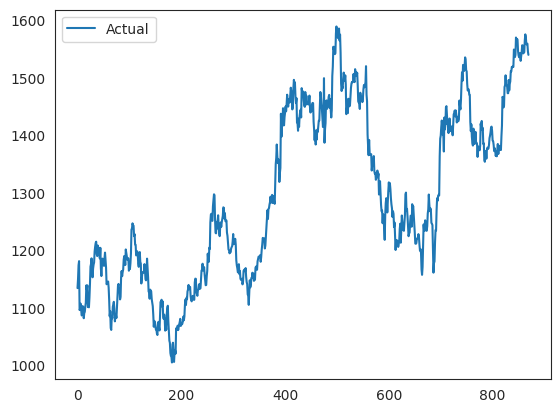

In [183]:
plot_new = np.arange(len(actual_vals))

plt.plot(plot_new, actual_vals, label="Actual")
plt.legend()
plt.show()


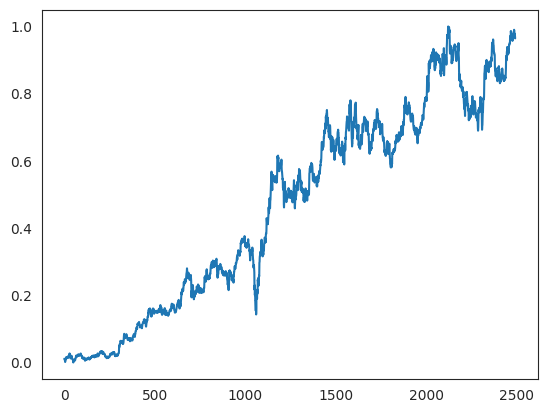

In [184]:
ds_new = ds_scaled.tolist()
plt.plot(ds_new)

In [185]:
len(ds_new)

2492

In [189]:
for idx, val in enumerate(ds_new[1700:]):
    if not isinstance(val, (int, float, np.number)):
        print(idx, val, type(val))
        break


0 [0.6763982934957381] <class 'list'>


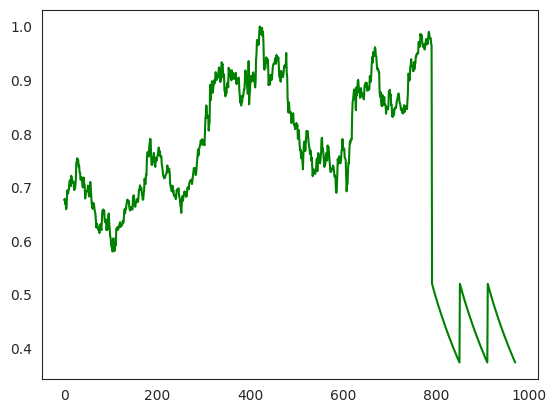

In [190]:
ds_new_clean = []

for x in ds_new:
    try:
        ds_new_clean.append(float(np.array(x).reshape(-1)[0]))
    except:
        print("Bad value:", x, type(x))
plt.plot(ds_new_clean[1700:], color='green')
plt.show()




In [192]:
#Creating final data for plotting
# Step 1 — Clean every element into a float
ds_new_clean = []

for x in ds_new:
    try:
        # Flatten any nested lists/arrays and convert to float
        ds_new_clean.append(float(np.array(x).reshape(-1)[0]))
    except:
        print("Bad value found:", x, type(x))

# Step 2 — Convert to 2D array for inverse_transform
ds_new_2d = np.array(ds_new_clean).reshape(-1, 1)

# Step 3 — Now safely inverse transform
final_graph = normalizer.inverse_transform(ds_new_2d).flatten().tolist()


In [194]:
# Convert lst_output to 2D array
lst_output_2d = np.array(lst_output).reshape(-1, 1)

# Inverse transform predictions
y_pred_vals = normalizer.inverse_transform(lst_output_2d).flatten().tolist()

# Build predicted series aligned with actual
y_predicted = [None] * 70 + y_pred_vals


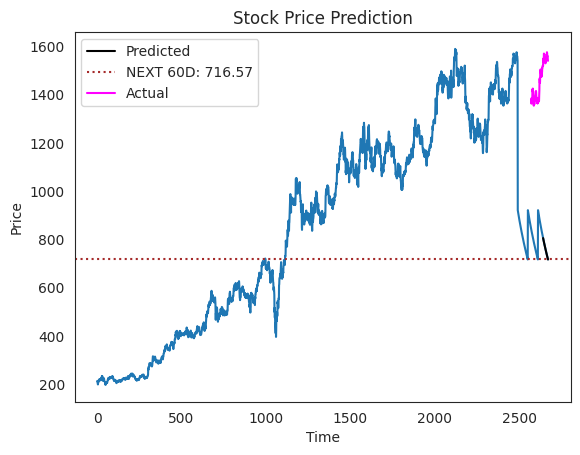

In [196]:

plt.plot(final_graph)

# Plot predicted values
plt.plot(x_predicted, y_predicted[-30:], color='black', label='Predicted')

# Predicted price after 60 days
predicted_price = y_predicted[-1]

# Corrected axhline
plt.axhline(
    y=final_graph[-1],
    color='brown',
    linestyle=':',
    label='NEXT 60D: {0}'.format(round(float(final_graph[-1]), 2))
)

# Actual values
plt.plot(x_actual, y_actual, color='magenta', label='Actual')

plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.show()



In [197]:
# Convert the predicted values to numpy array
y_predicted = np.array(test_predict)
# Inverse transform the predicted values to obtain the actual prices
y_predicted = normalizer.inverse_transform(y_predicted)
# Inverse transform the actual values to obtain the actual prices
y_actual = normalizer.inverse_transform(y_test.reshape(-1, 1))

# Calculate RMSE
RMSE_lstm = np.sqrt(mean_squared_error(y_actual, y_predicted))
print('RMSE:', RMSE_lstm)

# Calculate MAPE
MAPE_lstm = np.mean(np.abs((y_actual - y_predicted) / y_actual)) * 100
print('MAPE:',MAPE_lstm )

RMSE: 1846350.965922964
MAPE: 136266.09189490197


In [198]:
compare_model = {"MODEL":pd.Series(["Single Exponential","Holts Winter","Holts winter exp add sea and add trend","Holts winter exp mul sea and add trend","Holts winter exp mul sea and mul trend","Linear Model","Exponential Model","Quadratic Model","ARIMA Model(2,1,2)","Auto Regressor","Moving Average","SARIMAX(2,1,2)","SARIMAX(0,2,3)","LSTM(RNN)"]),
                 "RMSE_Values" :pd.Series([rmse_ses_model,rmse_hw_model,rmse_hwe_add_add_model,rmse_hwe_model_mul_add_model,rmse_hwe_model_mul_add_model,rmse_linear_model,rmse_Exp_model,rmse_Quad_model,RMSE_ARIMA ,RMSE_AR,RMSE_MA,RMSE_SARIMAX_a,RMSE_SARIMAX_1,RMSE_lstm]),
                 "MAPE_Values" :pd.Series([MAPE_ses_model,MAPE_hw_model,MAPE_hwe_add_add_model,MAPE_hwe_model_mul_add_model,MAPE_hwe_model_mul_add_model,MAPE_linear_model,MAPE_Exp_model,MAPE_Quad_model,MAPE_ARIMA ,MAPE_AR,MAPE_MA,MAPE_SARIMAX_a,MAPE_SARIMAX_1,MAPE_lstm])
                }
table_rmse=pd.DataFrame(compare_model)
table_rmse.sort_values(['MAPE_Values'])

,MODEL,RMSE_Values,MAPE_Values
12,"SARIMAX(0,2,3)",2.092774e+02,0.131874
13,LSTM(RNN),1.846351e+06,136266.091895
0,Single Exponential,NaN,NaN
1,Holts Winter,NaN,NaN
2,Holts winter exp add sea and add trend,NaN,NaN
3,Holts winter exp mul sea and add trend,NaN,NaN
4,Holts winter exp mul sea and mul trend,NaN,NaN
5,Linear Model,NaN,NaN
6,Exponential Model,NaN,NaN
7,Quadratic Model,NaN,NaN


Final Model:

In [200]:
final_sarimax = final_holt.fit()
final_sarimax.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                        RELIANCE.NS   No. Observations:                 2493
Model:             SARIMAX(0, 2, 3)x(0, 2, 3, 12)   Log Likelihood              -10174.507
Date:                            Sun, 04 Jan 2026   AIC                          20363.015
Time:                                    20:39:55   BIC                          20403.690
Sample:                                         0   HQIC                         20377.792
                                           - 2493                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9902      0.014    -71.784      0.000      -1.017      -0.963
ma.L2          0.0234      0.021      1.132      0.257      -0.017       0.064
ma.L3         -0.0237      0.016     -1.455      0.146      -0.056       0.008
ma.S.L12      -1.9883      0.030    -66.036      0.000      -2.047      -1.929
ma.S.L24       0.9805      0.039     25.284      0.000       0.905       1.057
ma.S.L36       0.0082      0.017      0.490      0.624      -0.025       0.041
sigma2       204.9194      6.358     32.231      0.000     192.458     217.381
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):              3555.90
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               7.21   Skew:                             0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [201]:
fitted = final_sarimax.fittedvalues.head(100)

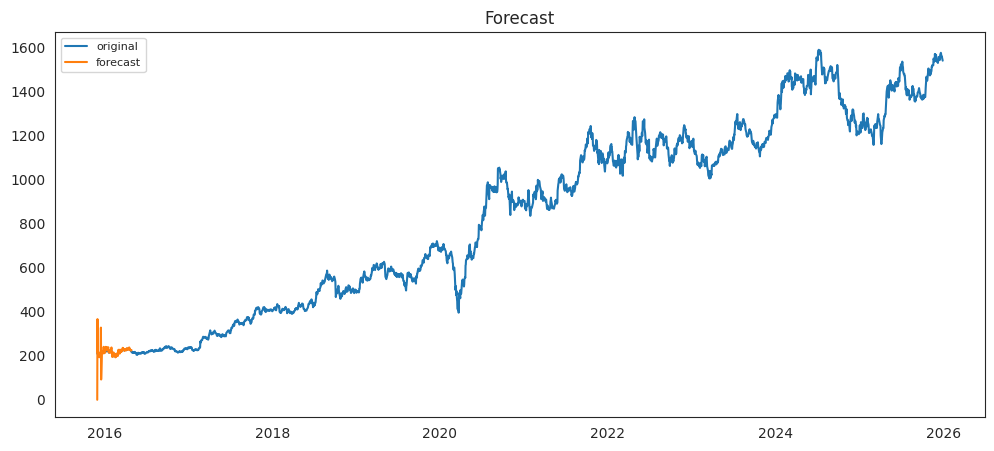

In [202]:

plt.figure(figsize=(12,5), dpi=100)
plt.plot(ari.Close, label='original')
plt.plot(fitted, label='forecast')
plt.title('Forecast')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [203]:
#Forecasting for next 5 years

pred_5=final_sarimax.forecast(5)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



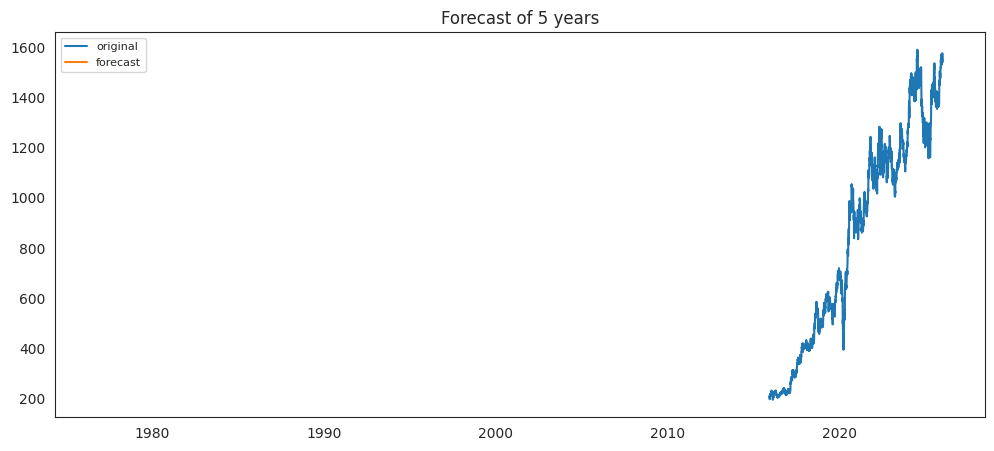

In [204]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(ari.Close, label='original')
plt.plot(pred_5, label='forecast')
plt.title('Forecast of 5 years')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [205]:
#Forecasting for next 10 years

pred_10=final_sarimax.forecast(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



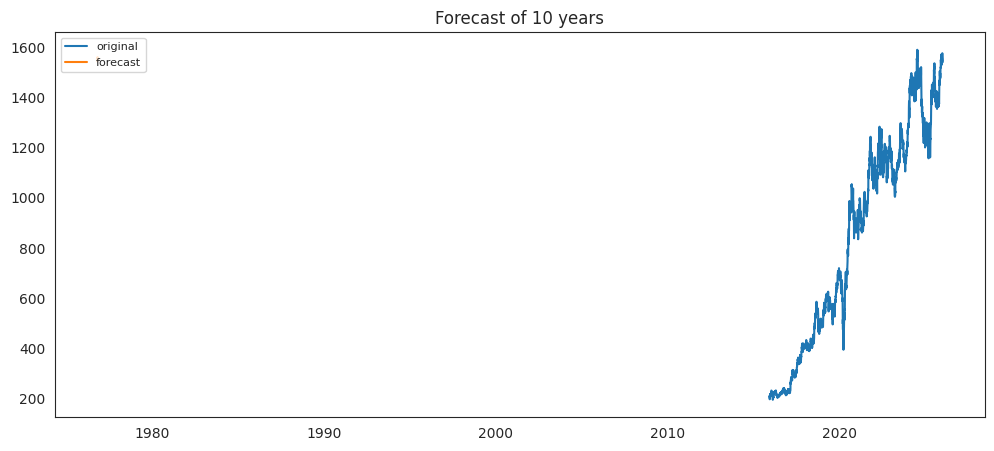

In [206]:
plt.figure(figsize=(12,5), dpi=100)
plt.plot(ari.Close, label='original')
plt.plot(pred_10, label='forecast')
plt.title('Forecast of 10 years')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [207]:
pred_15= final_sarimax.forecast(15)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



In [208]:

pred_15


,predicted_mean
2493,1543.213575
2494,1547.164559
2495,1549.299839
2496,1550.678564
2497,1553.977494
2498,1558.374186
2499,1560.059819
2500,1553.705934
2501,1552.286977
2502,1552.055735


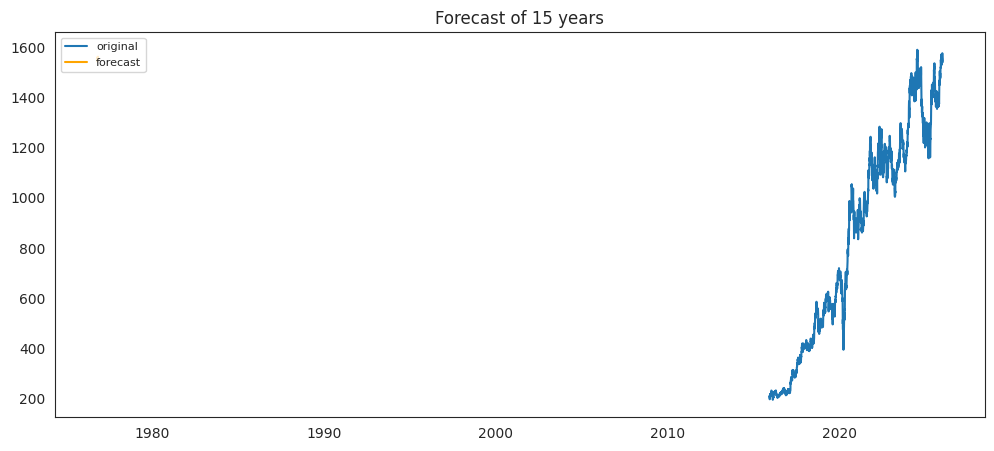

In [209]:

plt.figure(figsize=(12,5), dpi=100)
plt.plot(ari.Close, label='original')
plt.plot(pred_15, label='forecast',color='orange')
plt.title('Forecast of 15 years')
plt.legend(loc='upper left', fontsize=8)
plt.show()


In [ ]:
!pip install streamlit

In [ ]:
from pickle import load
from pickle import dump

In [ ]:
# Exporting to csv file
pred_15.to_csv(r'stockforecast_15years.csv',index=True)

In [ ]:

# Saving the pickle file
import pickle
pickle.dump(final_sarimax, open('Forecast_sarimax.pkl','wb'))